# Izbor atributa - Feature selection

Skup podataka o procesu proizvodnje poluprovodnika (semiconductor):

[SECOM - UCI](https://archive.ics.uci.edu/dataset/179/secom)

[SECOM - Kaggle](https://www.kaggle.com/datasets/paresh2047/uci-semcom)

In [ ]:
import time
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif,
    chi2,
    RFE,
    SequentialFeatureSelector,
    SelectFromModel,
    f_classif,
 )
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    matthews_corrcoef, 
    recall_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## Ucitavanje dataseta i pretprocesiranje

In [2]:
data_path="data/uci-secom.csv"

dataset = pd.read_csv(data_path)

In [3]:
print("Dataset shape:", dataset.shape)

Dataset shape: (1567, 592)


In [4]:
dataset.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [5]:
dataset.tail()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
1562,2008-10-16 15:13:00,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,2008-10-16 20:49:00,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2008-10-17 05:26:00,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2008-10-17 06:01:00,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1
1566,2008-10-17 06:07:00,2944.92,2450.76,2195.4444,2914.1792,1.5978,100.0,85.1011,0.1235,NaN,...,137.7844,0.4987,0.0181,0.0040,3.6275,0.0117,0.0162,0.0045,137.7844,-1


In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


In [7]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.4900,3056.6500,3356.3500
1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.4050,2538.8225,2846.4400
2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.0667,2218.0555,2315.2667
3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.2144,1591.2235,3715.0417
4,1553.0,4.197013,56.355540,0.6815,1.017700,1.3168,1.5257,1114.5366
...,...,...,...,...,...,...,...,...
586,1566.0,0.021458,0.012358,-0.0169,0.013425,0.0205,0.0276,0.1028
587,1566.0,0.016475,0.008808,0.0032,0.010600,0.0148,0.0203,0.0799
588,1566.0,0.005283,0.002867,0.0010,0.003300,0.0046,0.0064,0.0286
589,1566.0,99.670066,93.891919,0.0000,44.368600,71.9005,114.7497,737.3048


In [8]:
dataset_types = dataset.dtypes.value_counts()

print("Types of columns in the dataset:\n", dataset_types)

Types of columns in the dataset:
 float64    590
str          1
int64        1
Name: count, dtype: int64


In [9]:
int_columns = dataset.select_dtypes(include='int64').columns
print("Integer columns in the dataset:\n", list(int_columns))

object_columns = dataset.select_dtypes(include='object').columns
print("\nObject columns in the dataset:\n", list(object_columns))

Integer columns in the dataset:
 ['Pass/Fail']

Object columns in the dataset:
 ['Time']


In [10]:
target_unique = dataset['Pass/Fail'].unique()
print("\nUnique values in the target variable 'Pass/Fail':\n", target_unique)


Unique values in the target variable 'Pass/Fail':
 [-1  1]


### Uklanjanje kolone 'Time'

In [11]:
dataset = dataset.drop(['Time'], axis=1)
print(f"\nThere are {len(dataset.columns)} columns after dropping 'Time': {dataset.columns.tolist()}")


There are 591 columns after dropping 'Time': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151',

### Pretprocesiranje podataka

Istrazivanje skupa podataka u potrazi za nedostajucim vrednostima, duplikatima i bilo kakvim karakteristikama koje bi mogle da iskrive performanse modela.

#### Nedostajuce vrednosti

In [12]:
missing_values_count = dataset.isnull().sum()
print("Missing values per column:\n", missing_values_count)

print("\nPercentage of missing values per column:")
print((missing_values_count / len(dataset)) * 100)

columns_with_missing = np.count_nonzero(dataset.isna().sum())
print(f"\nColumns with missing values: {columns_with_missing}")

total_missing = dataset.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")

Missing values per column:
 0             6
1             7
2            14
3            14
4            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 591, dtype: int64

Percentage of missing values per column:
0            0.382897
1            0.446713
2            0.893427
3            0.893427
4            0.893427
               ...   
586          0.063816
587          0.063816
588          0.063816
589          0.063816
Pass/Fail    0.000000
Length: 591, dtype: float64

Columns with missing values: 538

Total missing values in dataset: 41951


In [13]:
print("\nTop 10 columns with most missing values:")
print(dataset.isna().sum().sort_values(ascending=False).head(10))


Top 10 columns with most missing values:
292    1429
293    1429
157    1429
158    1429
220    1341
358    1341
85     1341
492    1341
382    1018
384    1018
dtype: int64


In [14]:
print(f"\nWe can see that some columns are almost empty. They have 1429 null records out of {len(dataset)}")


We can see that some columns are almost empty. They have 1429 null records out of 1567


#### Duplikati

In [15]:
num_duplicates = dataset.duplicated().sum()
print(f"Total duplicate rows in dataset: {num_duplicates}")

Total duplicate rows in dataset: 0


### Podela dataseta

In [16]:
X = dataset.drop(columns=['Pass/Fail'])
y = dataset['Pass/Fail']

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} features.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

Dataset shape: 1567 samples, 590 features.
Training Set: (1175, 590)
Testing Set: (392, 590)


### Uklanjanje kolona sa velikim brojem nedostajucih vrednosti

Postoje mnoge kolone kod kojih fali vecina podataka, tako da ih mozemo smatrati beskorisnim. Kolone sa preko 50% nedostajucih vrednosti ce biti uklonjene. 

In [17]:
missing_threshold = 0.5
missing_columns = X_train.columns[X_train.isna().mean() > missing_threshold]

X_train_nona = X_train.drop(missing_columns, axis=1)
X_test_nona = X_test.drop(missing_columns, axis=1)

print(f'Removed {len(missing_columns)} features.\n')
print(f'There are {X_train_nona.shape[1]} features left.')

Removed 24 features.

There are 566 features left.


### Skaliranje podataka

Nedostajuce vrednosti ce biti popunjene pomocu KNNImputer-a (koji racuna rastojanje izmedju redova). Zbog toga moramo dodati korak skaliranja pre imputacije.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_nona)
X_test_scaled = scaler.transform(X_test_nona)

### Popunjavanje nedostajucih vrednosti

In [19]:
knn_imputer = KNNImputer(n_neighbors=5)

X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed = knn_imputer.transform(X_test_scaled)

# Scaled DataFrame to keep column names. Will be used for feature selection steps that require DataFrames
X_train_fs = pd.DataFrame(X_train_imputed, columns=X_train_nona.columns)
X_test_fs = pd.DataFrame(X_test_imputed, columns=X_train_nona.columns)

# Datasets with original units (for visualization)
X_train_final = pd.DataFrame(scaler.inverse_transform(X_train_imputed), 
                             columns=X_train_nona.columns)
X_test_final = pd.DataFrame(scaler.inverse_transform(X_test_imputed), 
                            columns=X_train_nona.columns)

In [20]:
total_missing_train = X_train_final.isnull().sum().sum()
print(f"\nTotal missing values in training dataset: {total_missing_train}")

total_missing_test = X_test_final.isnull().sum().sum()
print(f"\nTotal missing values in test dataset: {total_missing_test}")


Total missing values in training dataset: 0

Total missing values in test dataset: 0


### Analiza distribucije ciljne kolone

Proveravamo ucestalost svake klase u ciljnoj koloni kako bismo razumeli da li postoji znacajna neuravnotezenost klasa pre evaluacije modela.

In [21]:
print(f'Unique values in target variable: {y_train.unique()}')

Unique values in target variable: [-1  1]


Prema opisu skupa podataka:
- -1 odgovara klasi <b>Pass</b>
- 1 odgovara klasi <b>Fail</b>


Ovo cemo promeniti kako bi bilo intuitivnije za rad, tako da:
- 1 odgovara klasi <b>Pass</b>
- 0 odgovara klasi <b>Fail</b>

In [22]:
# 1 = Pass, 0 = Fail
y_train = y_train.replace({-1: 1, 1: 0})
y_test = y_test.replace({-1: 1, 1: 0})

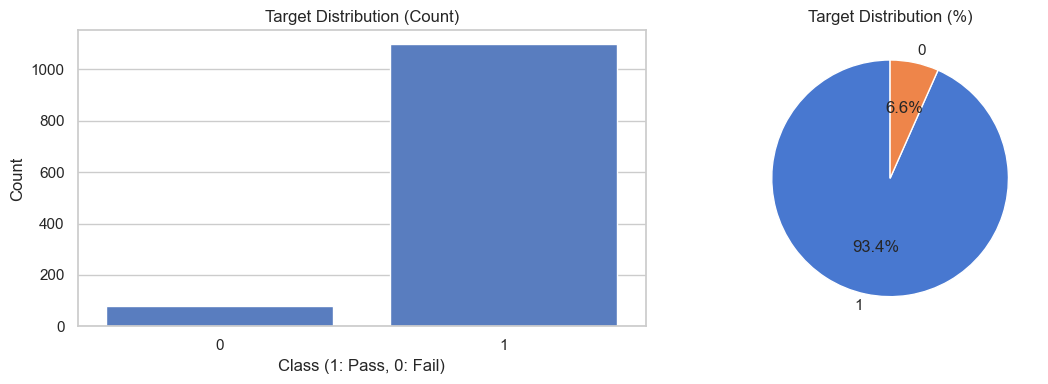

In [23]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Target Distribution (Count)")
axes[0].set_xlabel("Class (1: Pass, 0: Fail)")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Target Distribution (%)")

plt.tight_layout()
plt.show()

Vizuelizacija distribucije podataka nad nekoliko nasumicno odabranih kolona.

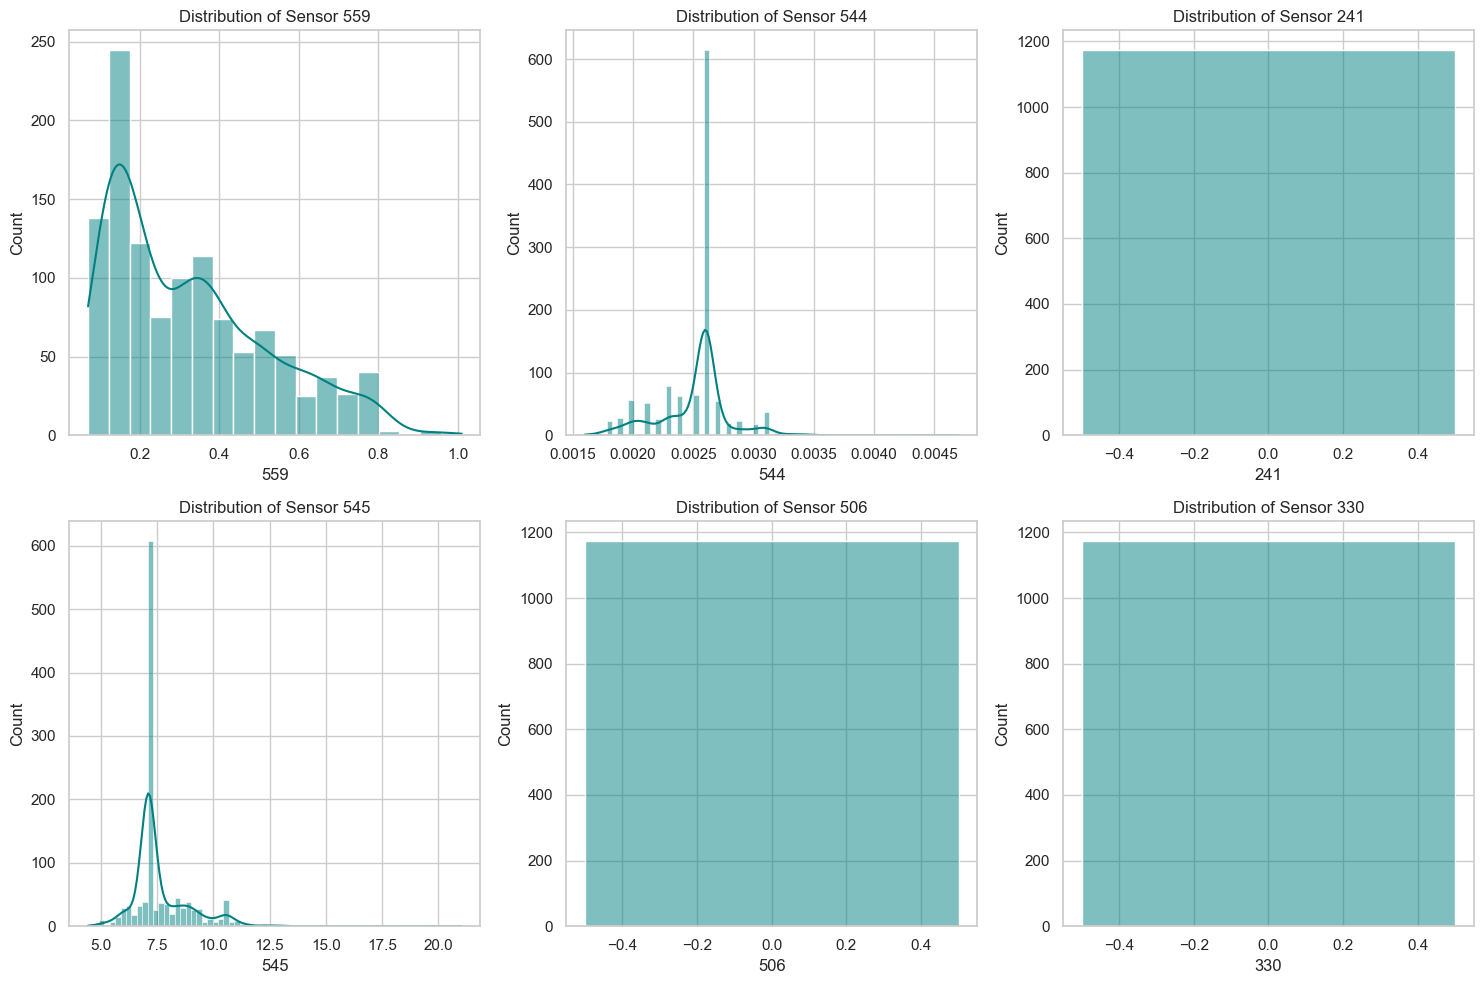

In [24]:
sample_cols = X_train_final.sample(n=6, axis=1, random_state=42).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(sample_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(X_train_final[col], kde=True, color='teal')
    plt.title(f'Distribution of Sensor {col}')
    plt.tight_layout()

plt.show()

In [25]:
# Convenience matrices reused across experiments
# Use the imputed feature matrices (no NaNs) created above (X_train_fs / X_test_fs).
baseline_n_features = X_train_fs.shape[1]

X_train_np = X_train_fs.to_numpy()
X_test_np = X_test_fs.to_numpy()

# X_train_fs/X_test_fs are already standardized (StandardScaler -> KNNImputer).
# Keep the conventional names for downstream sections.
X_train_scaled = X_train_np
X_test_scaled = X_test_np

# Non-negative scaling (required for Chi-square selector)
minmax = MinMaxScaler()
X_train_nonneg = minmax.fit_transform(X_train_np)
X_test_nonneg = minmax.transform(X_test_np)

Hi-kvadrat (Chi-Square) test uporedjuje posmatrane frekvencije. Matematicki ne moze da radi sa negativnim brojevima. Posto StandardScaler centrirа podatke oko $0$, otprilike polovina vrednosti ce biti negativna. Resenje je privremeno transformisanje podataka koristeci MinMaxScaler (koji skalira podatke izmedju $0$ i $1$) ili jednostavno pomeranje vrednosti tako da budu pozitivne.

Kada se koristi StandardScaler, varijansa svake kolone se postavalja na $1$. Problem je ako se pokrene VarianceThreshold nakon skaliranja, svaka kolona ce imati istu varijansu ($1.0$), pa metoda nece moci da razlikuje "visoko-informativne" i "nisko-informativne" senzore. Resenje je pokretanje Variance Threshold na X_train_nona (imputirani, ali neskalirani podaci) ili provera varijanse pre koraka skaliranja u pipeline-u.

## Metode evaluacije

Kao sto je ranije prikazano, ovaj skup podataka je veoma neuravnotezen, pa tacnost (accuracy) nije pouzdana metrika za evaluaciju. Naivan model koji uvek predvidja vecinsku klasu postigao bi preko 93% tacnosti, a da pri tome ne bi uspeo da prepozna nijedan defekt.

Za evaluaciju metoda selekcije karakteristika koristimo Matthews Correlation Coefficient (MCC) i macro F1-score, jer daju uravnotezen prikaz performansi kroz obe klase. Pored toga, pratimo i odziv (recall) za manjinsku klasu, posto je glavni cilj u ovom proizvodnom okruzenju prepoznavanje retkih slucajeva otkaza.


- **Matthews Correlation Coefficient (MCC)**: MCC je relativno neosetljiv na neuravnotezenost klasa. Daje rezultat od $+1$ (savrseno) do $-1$ (potpuno neslaganje), gde 0 predstavlja nasumicno pogadjanje, i efikasno kaznjava modele koji ignorisu $7\%$ manjinske klase. Ako metoda selekcije karakteristika zaista pomogne modelu da pronadje "greske" (klasa 0), MCC ce znacajno porasti. Tacnost se pritom nece mnogo promeniti. Visok skor se dobija samo ako model dobro radi na obe klase.
- **F1 Score**: F1 je pogodna metrika za modele testirane na neuravnotezenim skupovima podataka. Racuna F1 za svaku klasu posebno i zatim ih usrednjava, obezbedjujuci da je "Fail" klasa jednako vazna kao i "Pass" klasa.
- **Recall (Class 0)**: Meri osetljivost modela, odnosno procenat stvarnih proizvodnih defekata koji su otkriveni. U proizvodnji (SECOM), cilj je pronaci defekte. Izvestavanje o "Recall za klasu 0" pokazuje tacno koliko od tih 7% defekata je model zaista uhvatio. U proizvodnji poluprovodnika, "False Pass" (propusten kvar) je znatno skuplji od "False Fail" (slanje dobrog dela na ponovno testiranje). Prioritetizovanje recall-a za "Fail" klasu je ono sto zelimo.
- **ROC Curve**: Ovo nam pomaze da vidimo da li model zaista uci obrasce ili samo nasumicno osciluje. "Nazubljena" ROC kriva obicno ukazuje na preprilagodjavanje na specifican sum senzora.

In [26]:
# Dictionary to store performance metrics
registries = {
    "Filter": {},
    "Wrapper": {},
    "Embedded": {},
    "Hybrid": {},
}

In [27]:
def evaluate_selection_method(
    X_train_sel,
    X_test_sel,
    y_train,
    y_test,
    method_name,
    selection_time_sec,
    category,  # "Filter", "Wrapper", "Embedded", "Hybrid"
    original_num_features=None,
    estimator=None,
):
    # Mapping: 0 = Fail, 1 = Pass
    class_names = ['fail', 'pass']

   
    if estimator is None:
        estimator = LogisticRegression(
            class_weight='balanced',     # Using 'balanced' weight to handle imbalanced dataset
            C=1.0, 
            dual=False, 
            solver='liblinear',
            random_state = 42
        )

    # Measure Training Time
    start_train = time.time()
    estimator.fit(X_train_sel, y_train)
    train_time = time.time() - start_train
    
    # Inference
    y_pred = estimator.predict(X_test_sel)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro') 
    recall_fail = recall_score(y_test, y_pred, pos_label=0)

    total_time = selection_time_sec + train_time
    num_features = X_train_sel.shape[1]
    removed_features = None if original_num_features is None else int(original_num_features - num_features)
    reduction_pct = (1 - (num_features / original_num_features)) * 100 if original_num_features is not None else None

    print(f"\n{'='*60}")
    print(f"Method: {method_name}")
    print(f"Features: {num_features}")
    print(f"Removed features: {removed_features}")
    print(f"MCC Score: {mcc:.4f} | F1 (Macro): {f1_macro:.4f} | Recall (Class 0): {recall_fail:.4f}")
    print(f"Times: Selection {selection_time_sec:.2f}s | Train {train_time:.2f}s")
    print(f"{'='*60}")

    # Visualizations
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Evaluation: {method_name}", fontsize=16)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    ax[0].grid(False) 
    disp.plot(ax=ax[0], cmap='Blues', colorbar=False)
    ax[0].set_title("Confusion Matrix")

    # 2. Prediction Distribution
    sns.countplot(x=y_test, hue=y_pred, ax=ax[1], palette='viridis')
    ax[1].set_xticklabels(class_names)
    ax[1].set_title("Actual vs Predicted Counts")
    ax[1].set_xlabel("Actual Class")
    ax[1].legend(title="Predicted", labels=class_names)

    # 3. ROC Curve
    RocCurveDisplay.from_estimator(estimator, X_test_sel, y_test, ax=ax[2], color='darkorange')
    ax[2].plot([0, 1], [0, 1], 'k--', alpha=0.5) 
    ax[2].set_title("ROC AUC Curve")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    registries[category][method_name] = {
        'Num Features': int(num_features),
        'Reduction %': round(reduction_pct, 2),
        'MCC': round(mcc, 4),
        'F1 Macro': round(f1_macro, 4),
        'Accuracy': round(acc, 4),
        'Recall (Fail)': round(recall_fail, 4),
        'Selection Time (s)': round(selection_time_sec, 4),
        'Train Time (s)': round(train_time, 4),
        'Total Time (s)': round(total_time, 4)
    }

## Izvrsavanje eksperimenata

### Baseline (svi atributi)


Method: Baseline (All Features)
Features: 566
Removed features: 0
MCC Score: 0.1256 | F1 (Macro): 0.5506 | Recall (Class 0): 0.3077
Times: Selection 0.00s | Train 0.36s


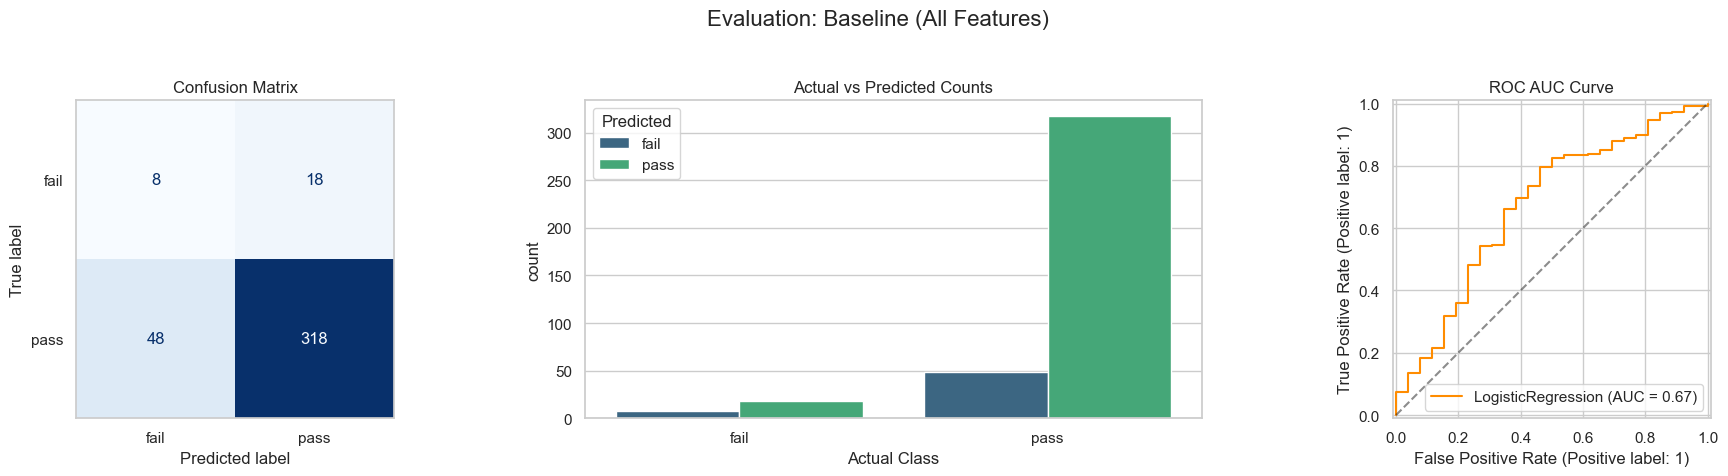

In [28]:
X_train_baseline = X_train_fs
X_test_baseline = X_test_fs

evaluate_selection_method(
    X_train_sel=X_train_baseline,
    X_test_sel=X_test_baseline,
    y_train=y_train,
    y_test=y_test,
    method_name="Baseline (All Features)",
    selection_time_sec=0.0,
    category="Filter",
    original_num_features=X_train_baseline.shape[1]
)

Ubacivanje 566 karakteristika u model sa samo oko 1175 trening uzoraka (75% od 1567) predstavlja klasicni "problem prokletstva dimenzionalnosti". Imamo veoma visok odnos karakteristika prema broju uzoraka, sto obicno dovodi do toga da model uci obrasce iz suma umesto iz stvarnog signala.

Recall za klasu 0 (0.3077): Uspevamo da uhvatimo samo ~31% stvarnih otkaza. U realnoj proizvodnji, propustanje 69% neispravnih instanci bi predstavljalo ozbiljan problem.

F1 Macro (0.5506): Znacajno je veci od MCC. Upravo zato je MCC ukljucen. F1 Macro je "povucen" sposobnoscu modela da lako prepoznaje "Pass" klasu, sto daje lazni osecaj sigurnosti.

### Filter metode
Svaku karakteristiku ocenjujemo nezavisno od bilo kog specificnog modela, a zatim zadrzavamo top-$k$ karakteristika (ili one koje su iznad odredjenog praga).

Bice obradjene sledece filter metode: 
- **Variance threshold**
- **Pearson correlation**
- **Chi-square**
- **Mutual information**
- **Information gain**
- **Fisher's score**

In [29]:
K_FILTER = 100 # keep top-k for score-based filters

#### Variance Threshold

Uklanja karakteristike sa niskom varijansom (one koje se malo menjaju).


Method: Variance Threshold
Features: 450
Removed features: 116
MCC Score: 0.1256 | F1 (Macro): 0.5506 | Recall (Class 0): 0.3077
Times: Selection 0.03s | Train 0.36s


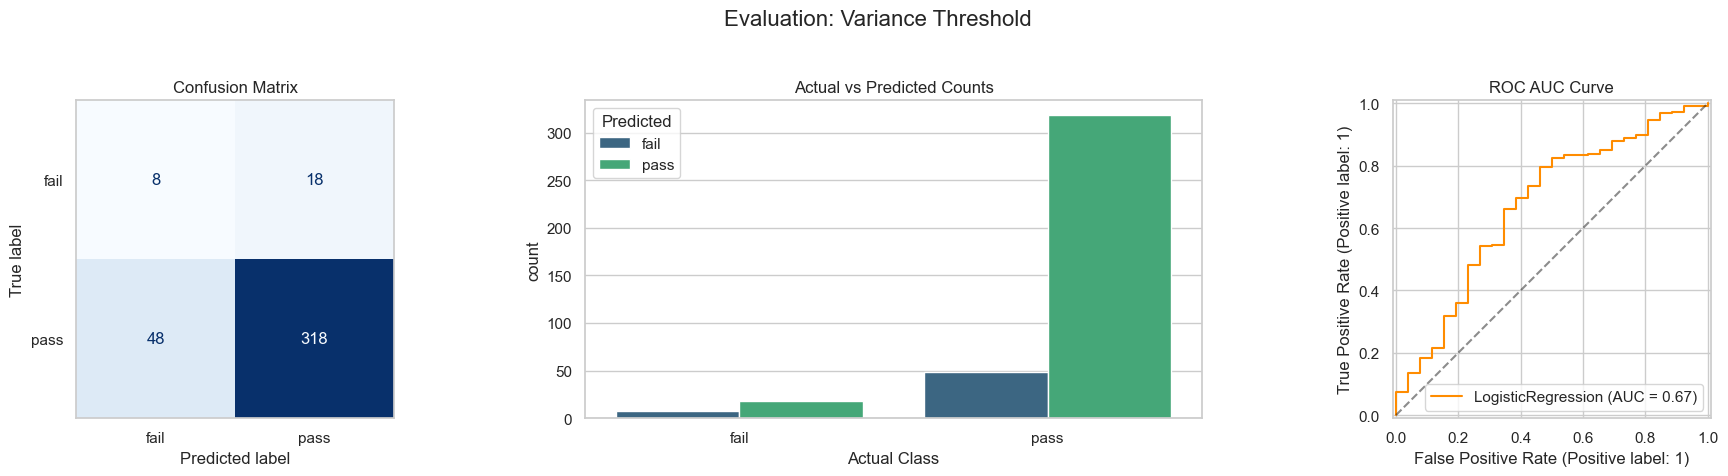

In [30]:
start_time = time.time()

# Using X_train_nona (unscaled) because scaling sets all variance to 1
selector = VarianceThreshold(threshold=0.1) 
X_train_var = selector.fit_transform(X_train_fs)
X_test_var = selector.transform(X_test_fs)
selection_time = time.time() - start_time

evaluate_selection_method(
    X_train_var, 
    X_test_var, 
    y_train, 
    y_test, 
    "Variance Threshold", 
    selection_time, 
    category="Filter",
    original_num_features=baseline_n_features
)

#### Pearson Correlation Coefficient

Uklanjaju se karakteristike koje su visoko korelisane jedna sa drugom (redundantne) ili zadrzavamo one koje su visoko korelisane sa ciljnom promenljivom.


Method: Pearson Correlation
Features: 50
Removed features: 516
MCC Score: 0.1733 | F1 (Macro): 0.5366 | Recall (Class 0): 0.5385
Times: Selection 1.02s | Train 0.03s


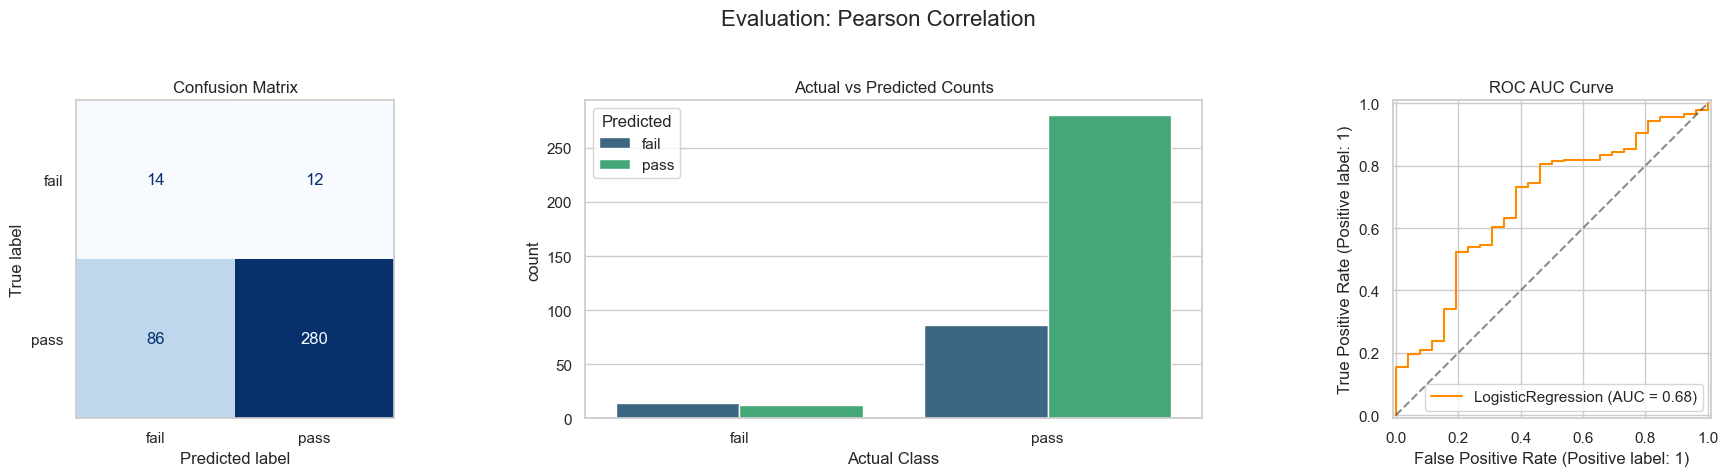

In [31]:
start_time = time.time()

# Calculate correlation matrix
temp_df = X_train_fs.copy()
temp_df['target_col'] = y_train.values

corr_matrix = temp_df.corr()
# Absolute correlation with target
target_corr = corr_matrix['target_col'].abs().sort_values(ascending=False)

# Select top 50 features (index 0 is 'target_col' itself, so we start from 1)
top_features = target_corr.index[1:51]

X_train_corr = X_train_fs[top_features]
X_test_corr = X_test_fs[top_features]
selection_time = time.time() - start_time

evaluate_selection_method(
    X_train_corr, 
    X_test_corr, 
    y_train, 
    y_test, 
    "Pearson Correlation", 
    selection_time, 
    category="Filter",
    original_num_features=baseline_n_features
)

#### Chi-Square Test

Zahteva nenegativne podatke, pa ovde koristimo MinMaxScaler.


Method: Chi-Square
Features: 50
Removed features: 516
MCC Score: 0.1965 | F1 (Macro): 0.5356 | Recall (Class 0): 0.6154
Times: Selection 0.03s | Train 0.01s


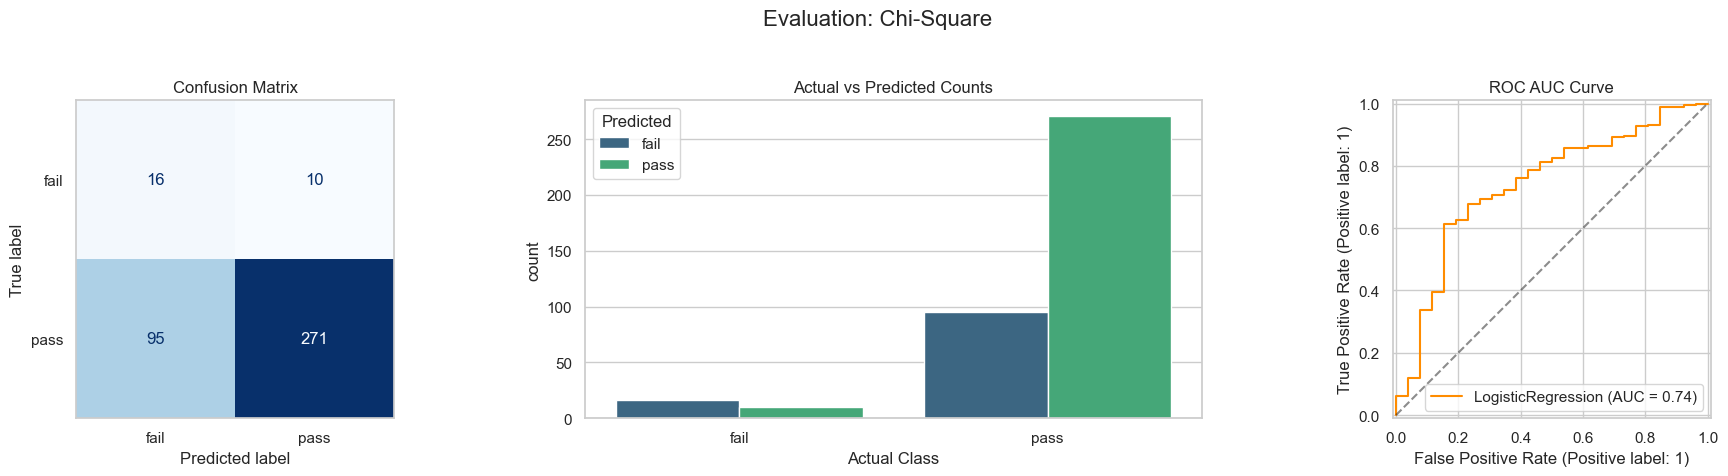

In [32]:
start_time = time.time()
# Shift data to [0, 1] range for Chi-Square
min_max = MinMaxScaler()
X_train_pos = min_max.fit_transform(X_train_fs)
X_test_pos = min_max.transform(X_test_fs)

selector = SelectKBest(chi2, k=50)
X_train_chi = selector.fit_transform(X_train_pos, y_train)
X_test_chi = selector.transform(X_test_pos)
selection_time = time.time() - start_time

evaluate_selection_method(
    X_train_chi, 
    X_test_chi, 
    y_train, 
    y_test, 
    "Chi-Square", 
    selection_time, 
    category="Filter",
    original_num_features=baseline_n_features
)

#### Mutual Information & Information Gain


Method: Mutual Information
Features: 50
Removed features: 516
MCC Score: 0.0970 | F1 (Macro): 0.4813 | Recall (Class 0): 0.5000
Times: Selection 3.89s | Train 0.02s


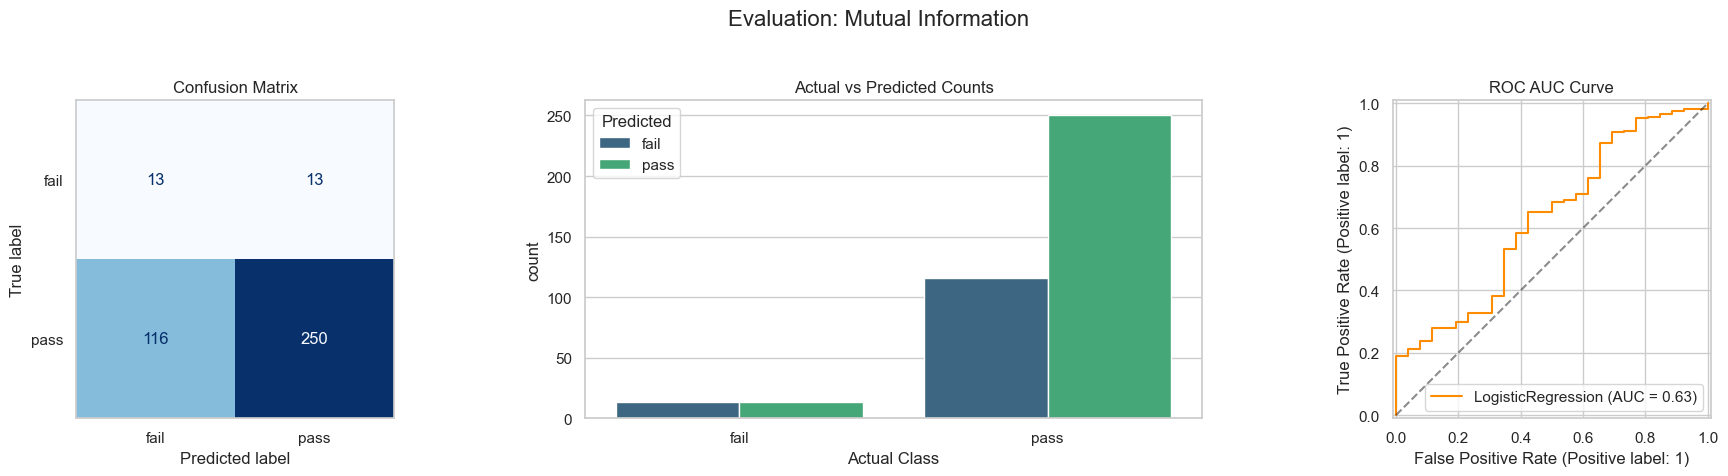

In [33]:
start_time = time.time()

mi_scores = mutual_info_classif(X_train_fs, y_train, random_state=42)
top_mi_indices = np.argsort(mi_scores)[-50:]

X_train_mi = X_train_fs.iloc[:, top_mi_indices]
X_test_mi = X_test_fs.iloc[:, top_mi_indices]
selection_time = time.time() - start_time

evaluate_selection_method(
    X_train_mi, 
    X_test_mi, 
    y_train, 
    y_test, 
    "Mutual Information", 
    selection_time, 
    category="Filter",
    original_num_features=baseline_n_features
)

#### Fisher's Score

Fisher-ov skor rangira karakteristike po njihovoj sposobnosti da maksimizuju varijansu izmedju klasa i minimizuju varijansu unutar klasa. Iako nije podrzan u Scikit-Learn-u, moze se izracunati pomocu skfeature biblioteke ili rucno preko F-statistike.


Method: Fisher's Score (F-Test)
Features: 50
Removed features: 516
MCC Score: 0.1733 | F1 (Macro): 0.5366 | Recall (Class 0): 0.5385
Times: Selection 0.03s | Train 0.03s


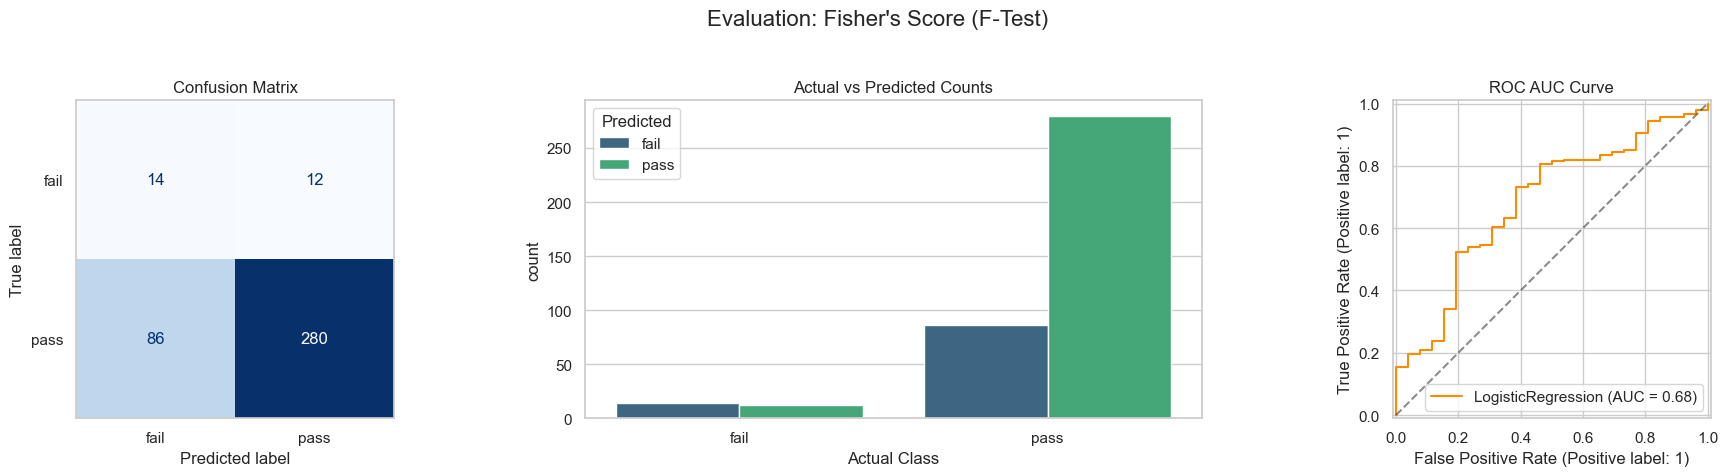

In [34]:
start_time = time.time()
selector = SelectKBest(f_classif, k=50)
X_train_fish = selector.fit_transform(X_train_fs, y_train)
X_test_fish = selector.transform(X_test_fs)
selection_time = time.time() - start_time

evaluate_selection_method(
    X_train_fish, 
    X_test_fish, 
    y_train, 
    y_test, 
    "Fisher's Score (F-Test)", 
    selection_time, 
    category="Filter",
    original_num_features=baseline_n_features
)

### Wrapper metode
Wrapper metode evaluiraju skupove karakteristika koristeci prediktivni model (za razliku od filter metoda koje ocenjuju svaku karakteristiku nezavisno). Ovo moze da uhvati interakcije izmedju senzora, ali je znacajno skuplje sa stanovista racunarske slozenosti.

Posto SECOM i dalje ima stotine karakteristika nakon ciscenja, prvo radimo **pre-filtriranje** na mali kandidat skup (WRAPPER_POOL) koristeci Mutual Information. Ovo odrzava vreme izvrsavanja wrapper-a razumnim, dok i dalje obezbedjuje kvalitetan skup kandidata.

U ovom delu istrazujemo tri klasicna wrapper pristupa:
- **SFS** (Sequential Forward Selection): pocinje od praznog skupa, i u svakom koraku dodaje najbolju karakteristiku.
- **SBE** (Sequential Backward Elimination): pocinje od kompletnog skupa, i u svakom koraku uklanja najlosiju karakteristiku.
- **RFE** (Recursive Feature Elimination): trenira model i iterativno uklanja najmanje vazne karakteristike.

**Napomena**: SECOM skup podataka je veoma neuravnotezen, pa se kao cilj optimizacije u wrapper pretrazi koristi macro F1 (ne tacnost), a osnovni estimator koristi `class_weight='balanced'`.

In [35]:
# Wrappers are expensive. We pre-filter to a small candidate pool first
# Use Chi-Square to get a candidate pool. 
# We use X_train_nonneg (from earlier MinMaxScaler)
WRAPPER_POOL_SIZE = 100                                 # Size of pre-filtered candidate pool for wrappers 
FEATURES_SELECT_SIZE = min(20, WRAPPER_POOL_SIZE)       # Final number of features to select with wrappers (must be <= WRAPPER_POOL_SIZE)
WRAPPER_SCORING = 'matthews_corrcoef'                   # Scoring metric for wrapper methods (MCC is good for imbalanced datasets)

start_pre = time.time()
pre_filter = SelectKBest(chi2, k=WRAPPER_POOL_SIZE)
X_train_pool = pre_filter.fit_transform(X_train_nonneg, y_train)
X_test_pool = pre_filter.transform(X_test_nonneg)
pre_time = time.time() - start_pre

# Base estimator for wrappers
wrapper_estimator = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=4000,
    random_state=42,
)

wrapper_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#### SFS - Sequential Forward Selection

SFS je pohlepna (greedy) forward pretraga: pocinje sa **praznim** skupom karakteristika i zatim u svakom koraku dodaje onu karakteristiku koja najvise poboljsava performanse dobijene unakrsnom validacijom (ovde je to macro F1).
- Dobro radi kada je samo mali broj senzora zaista informativan.
- Moze da propusti “sinergiju”, gde karakteristika postaje korisna tek kada je druga vec ukljucena (ogranicenje greedy pristupa).
- Slozenost raste otprilike kao $O(k \cdot p)$ fitovanja modela (unutar kandidat skupa), pa se zato koristi mali, pre-filtrirani skup.

##### SFS sa svim atributima


Method: SFS (Full Set -> 20)
Features: 20
Removed features: 546
MCC Score: 0.1641 | F1 (Macro): 0.5184 | Recall (Class 0): 0.5769
Times: Selection 303.36s | Train 0.00s


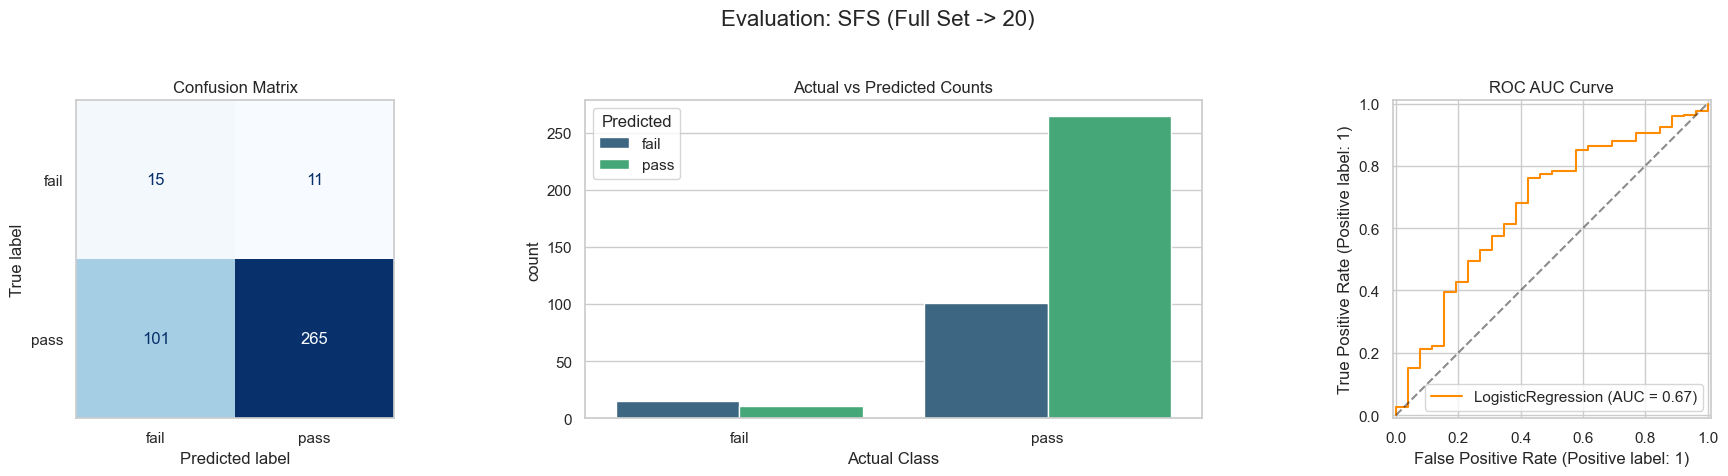

In [36]:
start_sel = time.time()

sfs_selector = SequentialFeatureSelector(
    wrapper_estimator,
    n_features_to_select=FEATURES_SELECT_SIZE, 
    direction='forward',
    scoring=WRAPPER_SCORING,
    cv=wrapper_cv,
    n_jobs=-1
)

X_train_sfs = sfs_selector.fit_transform(X_train_fs, y_train)
X_test_sfs = sfs_selector.transform(X_test_fs)
sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_sfs, 
    X_test_sfs, 
    y_train, 
    y_test, 
    f"SFS (Full Set -> {FEATURES_SELECT_SIZE})", 
    sel_time, 
    category="Wrapper",
    original_num_features=baseline_n_features
)

##### SFS sa smanjenim brojem atributa koriscenjem Chi-Square radi smanjenja vremena selekcije


Method: SFS (Chi2 Pool 100 -> 20)
Features: 20
Removed features: 546
MCC Score: 0.2006 | F1 (Macro): 0.5586 | Recall (Class 0): 0.5385
Times: Selection 45.87s | Train 0.00s


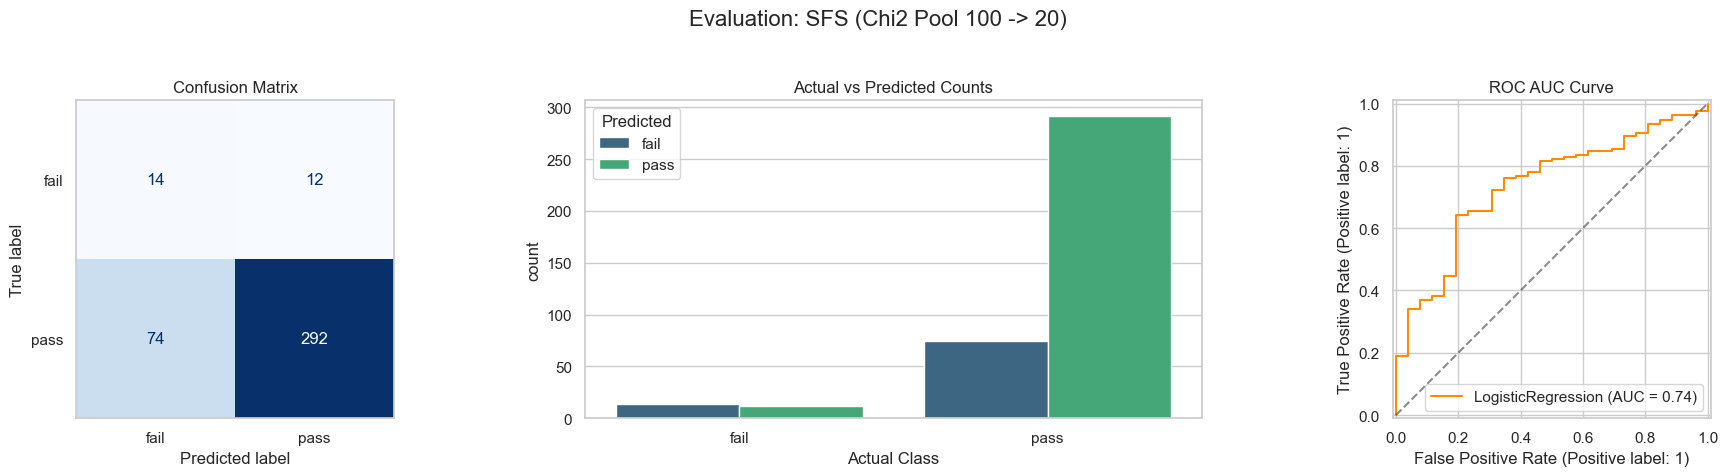

In [ ]:

start_sfs = time.time()
sfs_reduced = SequentialFeatureSelector(
    wrapper_estimator,
    n_features_to_select=FEATURES_SELECT_SIZE,
    direction='forward',
    scoring=WRAPPER_SCORING,
    cv=wrapper_cv,
    n_jobs=-1
)

X_train_sfs_red = sfs_reduced.fit_transform(X_train_pool, y_train)
X_test_sfs_red = sfs_reduced.transform(X_test_pool)
total_sel_time = pre_time + (time.time() - start_sfs)

evaluate_selection_method(
    X_train_sfs_red, 
    X_test_sfs_red, 
    y_train, 
    y_test, 
    f"SFS (Chi2 Pool {WRAPPER_POOL_SIZE} -> {FEATURES_SELECT_SIZE})", 
    total_sel_time, 
    category="Wrapper",
    original_num_features=baseline_n_features
)

#### SBE - Sequential Backward Elimination
SBE je backward verzija SFS-a: pocinje sa **svim** karakteristikama u kandidat skupu i uklanja onu karakteristiku cije uklanjanje najmanje pogorsava cross-validation skor.
- Moze raditi bolje od SFS-a kada je mnogo karakteristika umereno korisno.
- Obicno je skuplji od SFS-a kada je $p$ veliki, pa se i dalje ogranicava na mali skup kandidata.
- Kao i SFS, pohlepnog je tipa i ne garantuje pronalazak globalnog optimuma.

##### SBE sa redukovanim brojem atributa


Method: SBE (Chi2 Pool 100 → 20)
Features: 20
Removed features: 546
MCC Score: 0.1839 | F1 (Macro): 0.5354 | Recall (Class 0): 0.5769
Times: Selection 161.91s | Train 0.00s


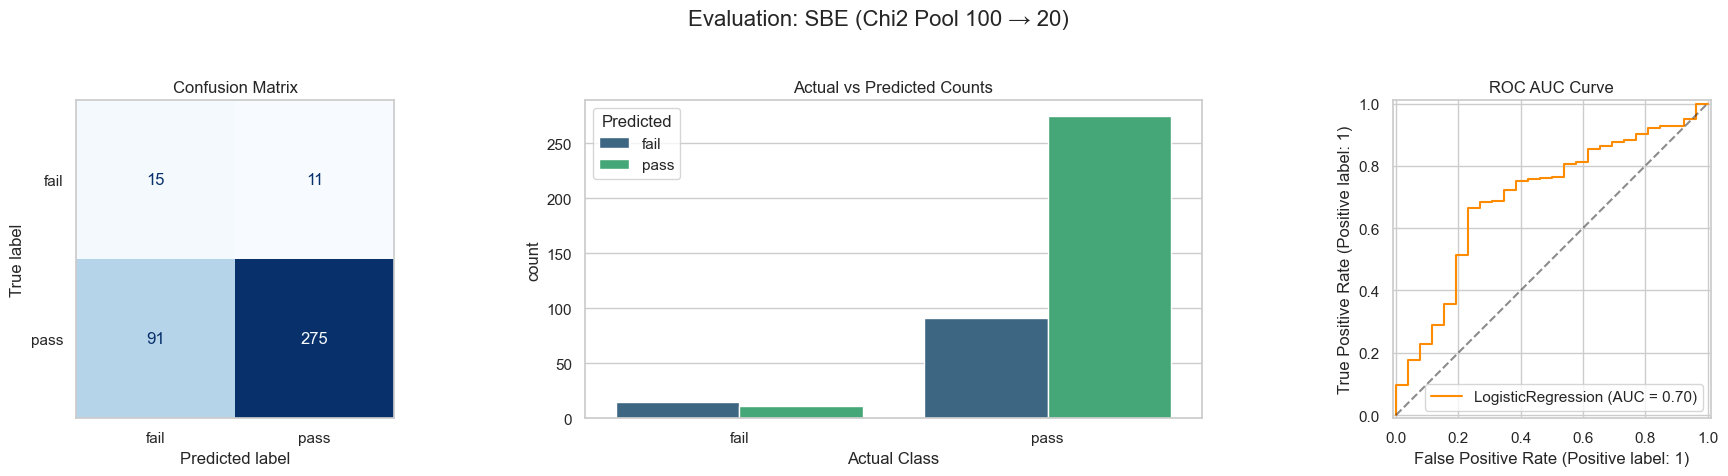

In [38]:
start_sel = time.time()
sbe = SequentialFeatureSelector(
    wrapper_estimator,
    n_features_to_select=FEATURES_SELECT_SIZE,
    direction='backward',
    scoring=WRAPPER_SCORING,
    cv=wrapper_cv,
    n_jobs=-1,
)
X_train_sbe = sbe.fit_transform(X_train_pool, y_train)
X_test_sbe = sbe.transform(X_test_pool)
sel_time = time.time() - start_sel + pre_time

evaluate_selection_method(
    X_train_sel=X_train_sbe,
    X_test_sel=X_test_sbe,
    y_train=y_train,
    y_test=y_test,
    method_name=f"SBE (Chi2 Pool {WRAPPER_POOL_SIZE} → {FEATURES_SELECT_SIZE})",
    selection_time_sec=sel_time,
    category="Wrapper",
    original_num_features=baseline_n_features,
)

#### RFE - Recursive Feature Elimination
RFE vise puta trenira estimator i u svakoj iteraciji uklanja najmanje vazne karakteristike (vaznost = apsolutna vrednost koeficijenata kod linearnih modela).
- Cesto je dobar baseline kada je signal blizu linearnog ili polu-linearnog.
- Osetljiv je na multikolinearnost: korelisani senzori mogu “deliti” vaznost.
- Vreme izvrsavanja zavisi od velicine pool-a i step parametra (koliko karakteristika se uklanja po iteraciji). Zato se pre RFE koristi pre-filtering kako bi se metoda odrzala izvodljivom.

#### RFE sa svim atributima


Method: RFE (Full Set -> 20)
Features: 20
Removed features: 546
MCC Score: 0.2675 | F1 (Macro): 0.5421 | Recall (Class 0): 0.8077
Times: Selection 2.40s | Train 0.01s


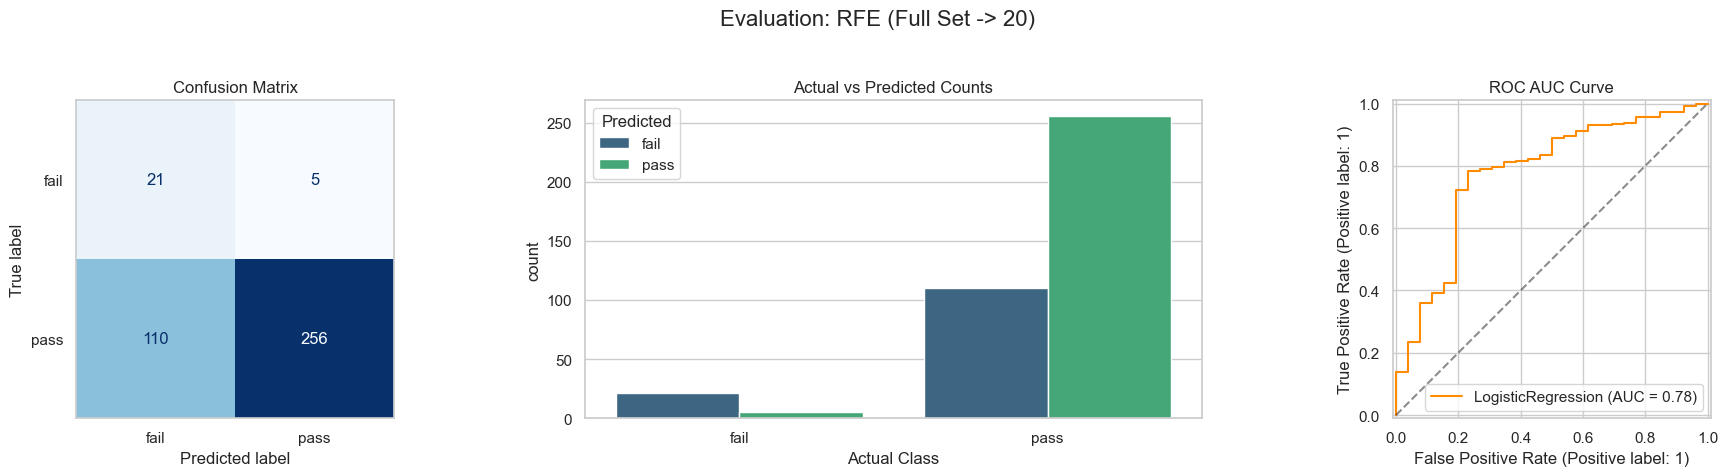

In [ ]:
start_sel = time.time()

rfe_selector = RFE(
    estimator=wrapper_estimator, 
    n_features_to_select=FEATURES_SELECT_SIZE, 
    step=50 
)

X_train_rfe = rfe_selector.fit_transform(X_train_fs, y_train)
X_test_rfe = rfe_selector.transform(X_test_fs)
sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_rfe, 
    X_test_rfe, 
    y_train, 
    y_test, 
    f"RFE (Full Set -> {FEATURES_SELECT_SIZE})", 
    sel_time, 
    category="Wrapper",
    original_num_features=baseline_n_features
)

##### RFE sa redukovanim brojem atributa


Method: RFE (F-test pool 100 → 20)
Features: 20
Removed features: 546
MCC Score: 0.2193 | F1 (Macro): 0.5445 | Recall (Class 0): 0.6538
Times: Selection 3.19s | Train 0.00s


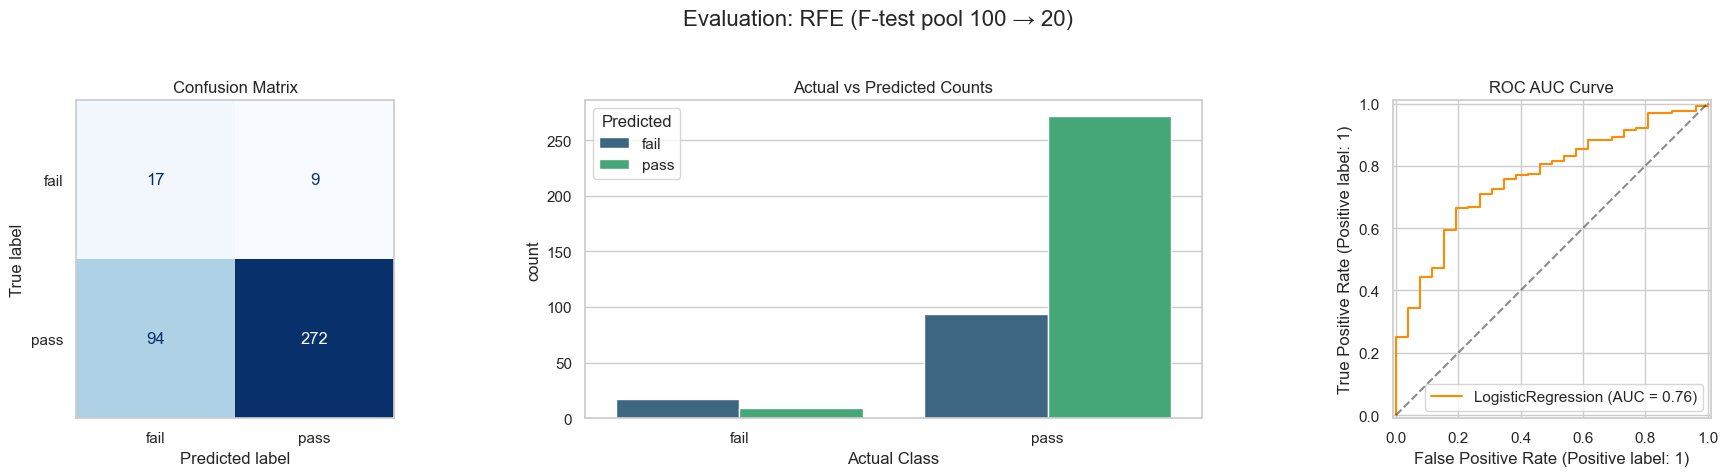

In [40]:
RFE_POOL_SIZE = 100
RFE_SELECT = min(20, RFE_POOL_SIZE)

start_pre = time.time()
rfe_pool_selector = SelectKBest(chi2, k=RFE_POOL_SIZE)
X_train_rfe_pool = rfe_pool_selector.fit_transform(X_train_nonneg, y_train)
X_test_rfe_pool = rfe_pool_selector.transform(X_test_nonneg)
pre_time = time.time() - start_pre


# Drop ~10% of remaining features per iteration for speed
rfe_step = max(1, int(round(0.10 * RFE_POOL_SIZE)))
rfe = RFE(
    wrapper_estimator, 
    n_features_to_select=RFE_SELECT, 
    step=rfe_step
)
X_train_rfe = rfe.fit_transform(X_train_rfe_pool, y_train)
X_test_rfe = rfe.transform(X_test_rfe_pool)
sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_sel=X_train_rfe,
    X_test_sel=X_test_rfe,
    y_train=y_train,
    y_test=y_test,
    method_name=f"RFE (F-test pool {RFE_POOL_SIZE} → {RFE_SELECT})",
    selection_time_sec=sel_time,
    category="Wrapper",
    original_num_features=baseline_n_features,
)

### Embedded metode
Ugradjene (embedded) metode vrse selekciju tokom samog treniranja modela (npr. pomocu regularizacije ili podela zasnovanih na stablima).

Ovde ce biti obradjeni: 
- **LASSO**
- **Ridge**
- **ElasticNet**
- **Decision trees and ensembles (stabla odluke i ansambli)**

**Izbor za SECOM dataset:**
- Koritimo `class_weight='balanced'` unutra modela za *selekciju* kada je to primenljivo, kako bi izabrane karakteristike bile korisnije za prepoznavanje manjinske klase (Fail = 0).
- Evaluacija se i dalje vrsi pomocu `evaluate_selection_method(...)` koja prikazuje MCC, makro-F1 i Recall za klasu 0.

#### LASSO (L1 Logistic Regression)
LASSO je ugradjena metoda za selekciju karakteristika zato sto L1 kazna tokom treniranja dovodi mnoge koeficijente tacno na nulu. Zadrzavaju se karakteristike ciji koeficijenti nisu jednaki nuli.

- Najbolje funkcionise kada je stvarni signal redak (sparse).
- Kod jace regularizacije moze izabrati *nula* karakteristika. Zbog toga ukljucujemo bezbednu rezervnu opciju (fallback).

The LASSO model found 5 features with non-zero weights.

Method: LASSO (L1), C=0.01
Features: 5
Removed features: 561
MCC Score: 0.2707 | F1 (Macro): 0.6035 | Recall (Class 0): 0.5769
Times: Selection 0.05s | Train 0.00s


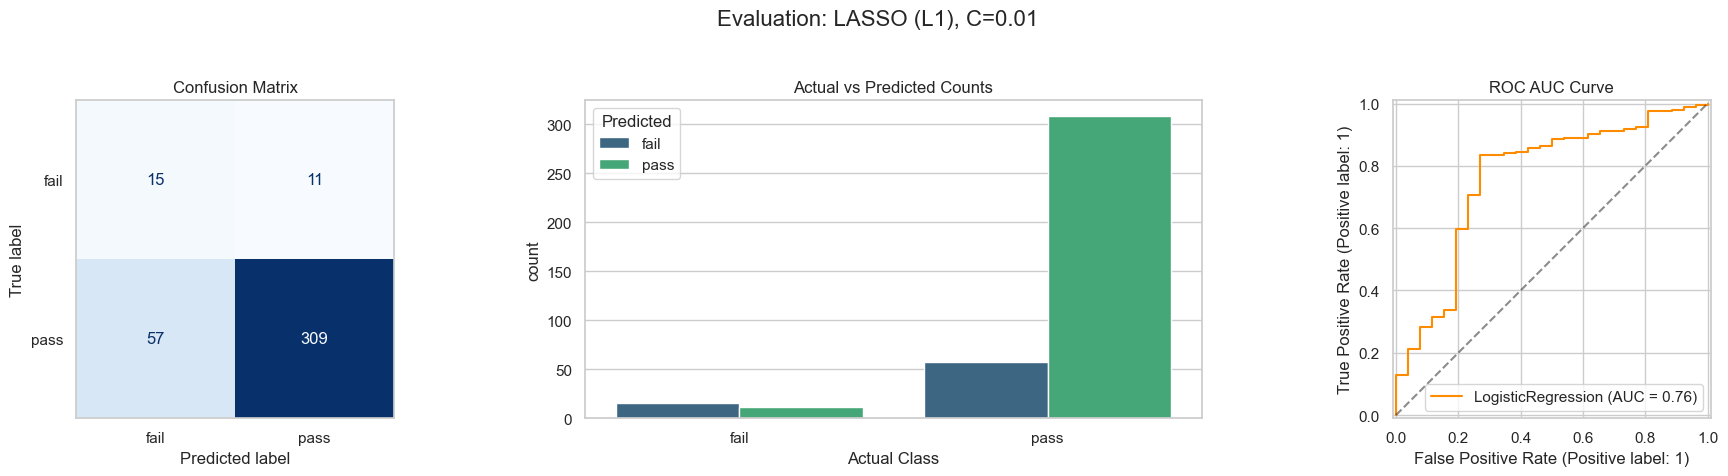

In [ ]:
start_sel = time.time()

# By setting C=0.01, we are applying extremely aggressive regularization that will drive most coefficients to zero, 
# leaving only the strongest signals.
embedded_selector = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    C=0.01, 
    class_weight='balanced', 
    random_state=42
)
embedded_selector.fit(X_train_np, y_train)
raw_non_zero = np.sum(embedded_selector.coef_ != 0)
print(f"The LASSO model found {raw_non_zero} features with non-zero weights.")

# threshold=1e-5 means anything basically not zero
# max_features=50 ensures we don't get an explosion of features
sfm = SelectFromModel(
    embedded_selector, 
    threshold=1e-5, 
    max_features=50,
    prefit=True  # Since we've already fit the model, we set prefit=True to use it directly
)

X_train_lasso_simple = sfm.fit_transform(X_train_np, y_train)
X_test_lasso_simple = sfm.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_lasso_simple, 
    X_test_lasso_simple, 
    y_train, 
    y_test, 
    f"LASSO (L1), C=0.01", 
    sel_time, 
    category="Embedded",
    original_num_features=baseline_n_features
)

The LASSO model found 217 features with non-zero weights.

Method: LASSO (L1), C=1.0
Features: 50
Removed features: 516
MCC Score: 0.1678 | F1 (Macro): 0.5508 | Recall (Class 0): 0.4615
Times: Selection 1.76s | Train 0.02s


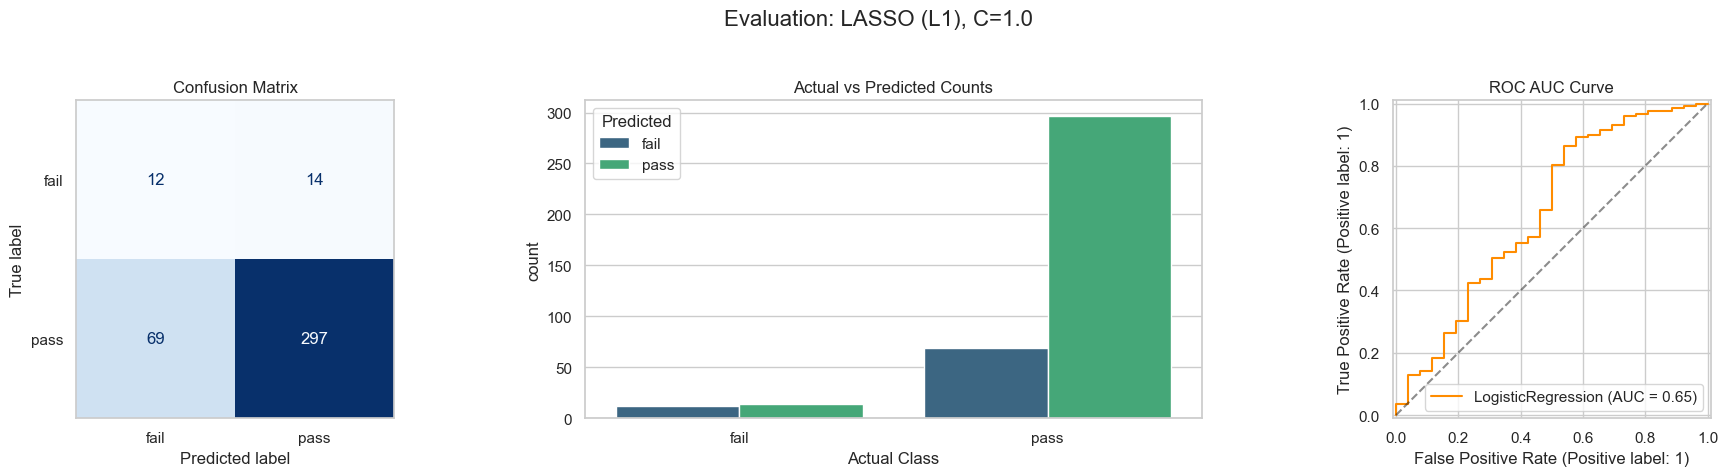

In [ ]:
start_sel = time.time()

embedded_selector = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    C=1.0, 
    class_weight='balanced', 
    random_state=42
)
embedded_selector.fit(X_train_np, y_train)
raw_non_zero = np.sum(embedded_selector.coef_ != 0)
print(f"The LASSO model found {raw_non_zero} features with non-zero weights.")

# threshold=1e-5 means anything basically not zero
# max_features=50 ensures we don't get an explosion of features
sfm = SelectFromModel(
    embedded_selector, 
    threshold=1e-5, 
    max_features=50,
    prefit=True
)

X_train_lasso_simple = sfm.fit_transform(X_train_np, y_train)
X_test_lasso_simple = sfm.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_lasso_simple, 
    X_test_lasso_simple, 
    y_train, 
    y_test, 
    f"LASSO (L1), C=1.0", 
    sel_time, 
    category="Embedded",
    original_num_features=baseline_n_features
)

#### Ridge (L2 Logistic Regression)
Ridge je ugradjena metoda u smislu da model tokom treniranja uci koeficijente, ali **L2 ne stvara retkost (sparsity)**. Da bismo ga pretvorili u metodu za selekciju karakteristika, rangiramo karakteristike prema apsolutnoj vrednosti koeficijenata i zadrzavamo prvih $k$.

- Stabilniji je od LASSO metode u uslovima multikolinearnosti (korelisanih senzora).
- U ovom pristupu uvek bira tacno $k$ karakteristika.

The Ridge model found 450 features with non-zero weights.

Method: Ridge (L2), C=1.0
Features: 50
Removed features: 516
MCC Score: 0.2303 | F1 (Macro): 0.5729 | Recall (Class 0): 0.5769
Times: Selection 0.12s | Train 0.02s


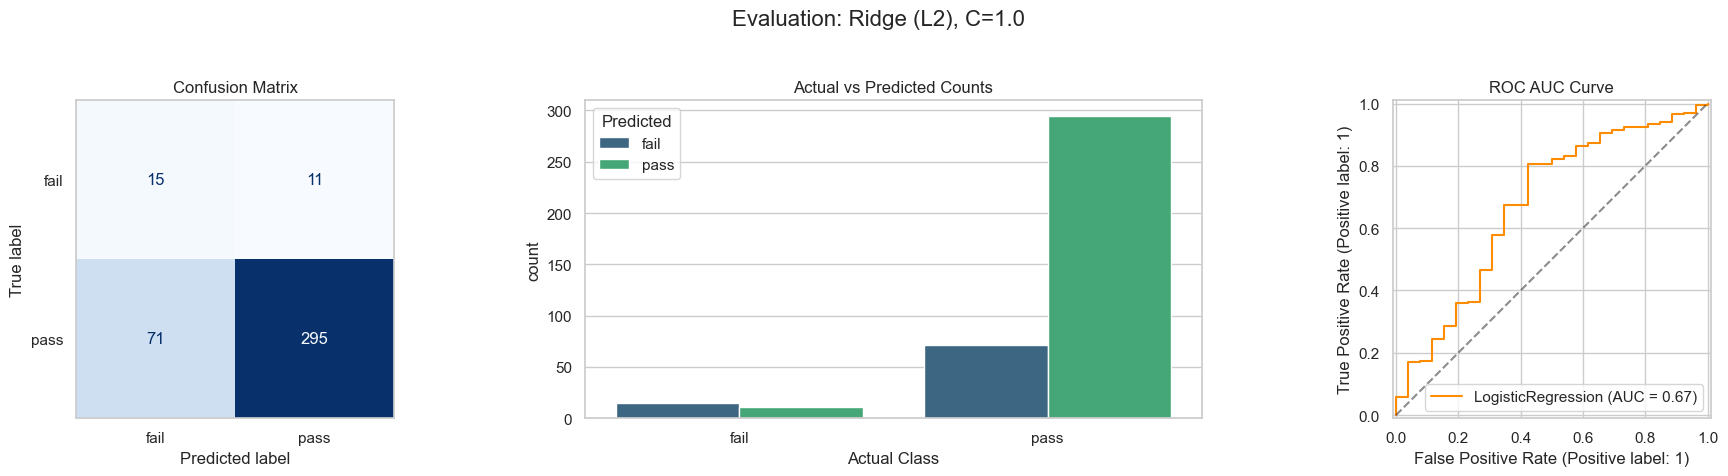

In [43]:
start_sel = time.time()

ridge_selector = LogisticRegression(
    penalty='l2', 
    solver='lbfgs', 
    C=1.0, 
    class_weight='balanced', 
    max_iter=6000,
    random_state=42
)
ridge_selector.fit(X_train_np, y_train)
raw_non_zero = np.sum(ridge_selector.coef_ != 0)
print(f"The Ridge model found {raw_non_zero} features with non-zero weights.")

sfm_ridge = SelectFromModel(
    ridge_selector, 
    max_features=50,
    threshold=1e-5,
    prefit=True  
)

X_train_ridge_simple = sfm_ridge.fit_transform(X_train_np, y_train)
X_test_ridge_simple = sfm_ridge.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_ridge_simple, 
    X_test_ridge_simple, 
    y_train, 
    y_test, 
    f"Ridge (L2), C=1.0", 
    sel_time, 
    category="Embedded",
    original_num_features=baseline_n_features
)

#### ElasticNet (L1 + L2)
ElasticNet kombinuje L1 (retkost) i L2 (stabilnost) regularizaciju. Cesto predstavlja dobar kompromis na skupovima podataka sa korelisanim karakteristikama (sto je cesto slucaj kod nizova senzora).

- Kao i LASSO, moze proizvesti koeficijente koji su tacno jednaki nuli (selekcija karakteristika).
- Parametar `l1_ratio` odredjuje koliko ce resenje biti retko.

The ElasticNet model found 379 features with non-zero weights.

Method: ElasticNet (L1+L2), C=1.0
Features: 50
Removed features: 516
MCC Score: 0.1003 | F1 (Macro): 0.5160 | Recall (Class 0): 0.3846
Times: Selection 37.47s | Train 0.02s


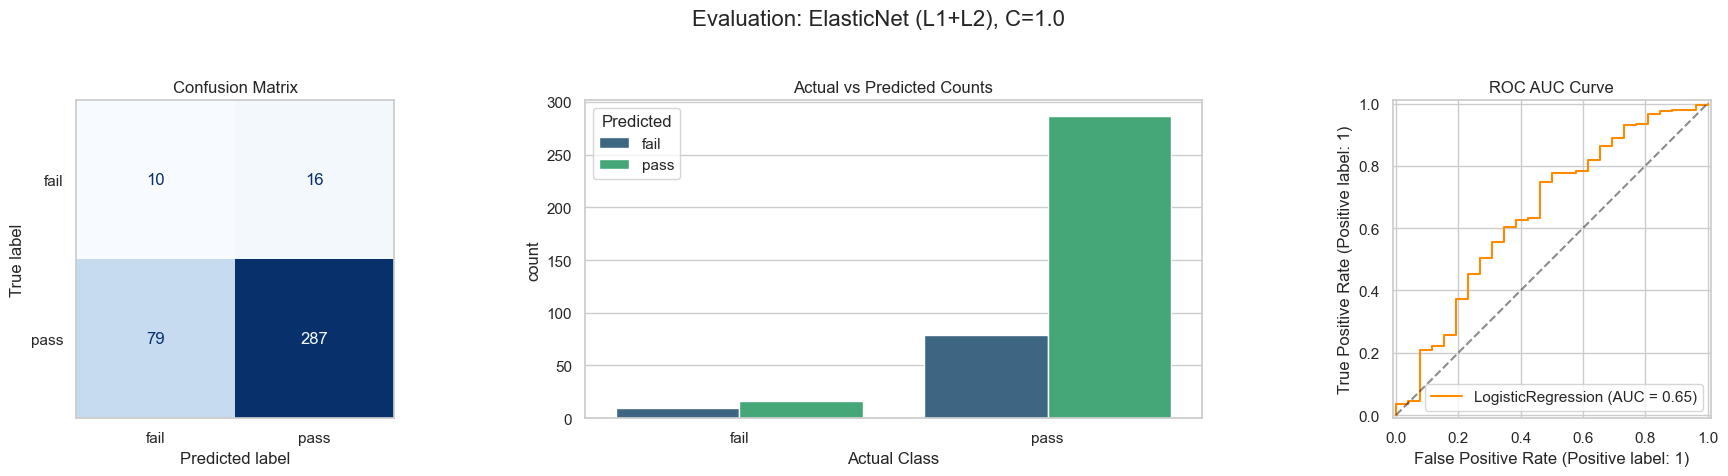

In [44]:
start_sel = time.time()

enet_selector = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    l1_ratio=0.5,     # 50/50 mix of L1 and L2
    C=1.0, 
    class_weight='balanced', 
    max_iter=8000,    # saga often needs more iterations to converge
    random_state=42
)
enet_selector.fit(X_train_np, y_train)

# Count how many coefficients are not zero
raw_non_zero = np.sum(enet_selector.coef_ != 0)
print(f"The ElasticNet model found {raw_non_zero} features with non-zero weights.")

sfm_enet = SelectFromModel(
    enet_selector, 
    max_features=50,
    threshold=1e-5,
    prefit=True 
)

X_train_enet_simple = sfm_enet.fit_transform(X_train_np, y_train)
X_test_enet_simple = sfm_enet.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_enet_simple, 
    X_test_enet_simple, 
    y_train, 
    y_test, 
    f"ElasticNet (L1+L2), C=1.0", 
    sel_time, 
    category="Embedded",
    original_num_features=baseline_n_features
)

#### Decision Trees (feature importance)
Modeli zasnovani na stablima predstavljaju ugradjene metode za selekciju karakteristika zato sto tokom treniranja uce pravila podele. Karakteristike se mogu rangirati prema njihovoj vaznosti zasnovanoj na smanjenju necistoce (impurity), nakon cega se zadrzava prvih $k$.

- Procena vaznosti moze biti pristrasna u korist kontinualnih ili sumovitih karakteristika, kao i karakteristika sa velikim brojem mogucih tacaka podele.
- Koriscenje `class_weight='balanced'` omogucava da podele posvete vise paznje manjinskoj klasi.

The Decision Tree model found 67 features with non-zero weights.

Method: Decision Tree (Gini)
Features: 55
Removed features: 511
MCC Score: 0.0293 | F1 (Macro): 0.4668 | Recall (Class 0): 0.3462
Times: Selection 0.50s | Train 0.02s


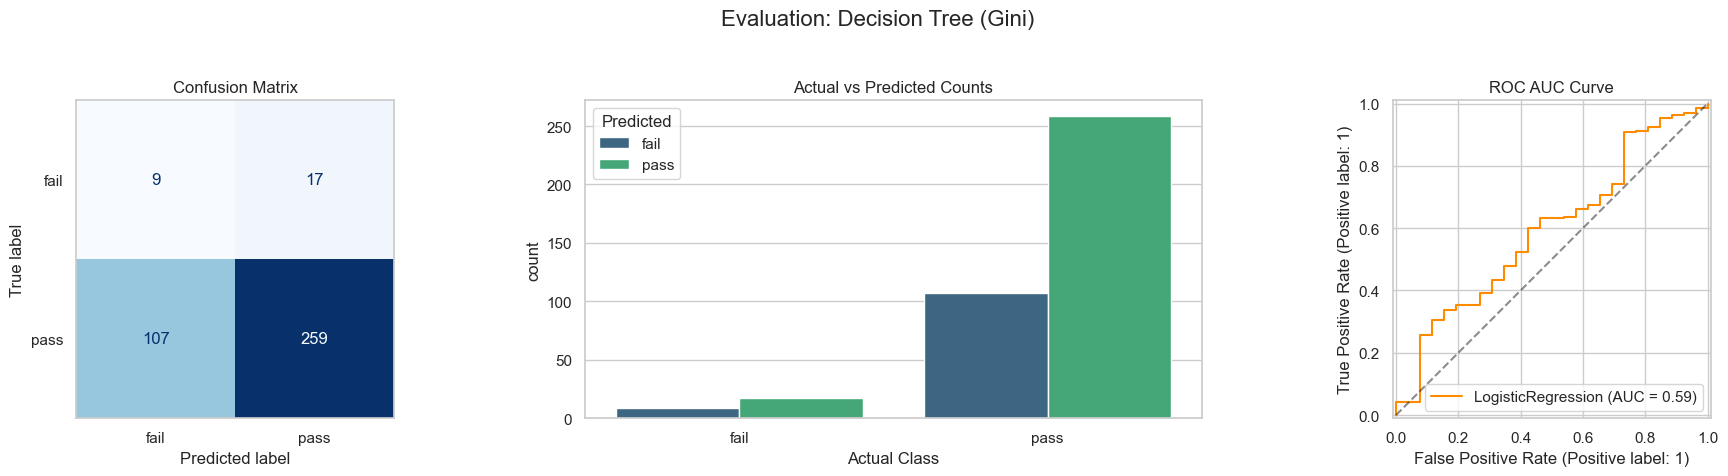

In [45]:
MAX_FEATURES=200

start_sel = time.time()

dt_selector = DecisionTreeClassifier(
    criterion='gini',
    class_weight='balanced',
    random_state=42
)
dt_selector.fit(X_train_np, y_train)
raw_non_zero = np.sum(dt_selector.feature_importances_ != 0)
print(f"The Decision Tree model found {raw_non_zero} features with non-zero weights.")

sfm_dt = SelectFromModel(
    dt_selector, 
    max_features=MAX_FEATURES,
    threshold=1e-5,
    prefit=True
)

X_train_dt_simple = sfm_dt.fit_transform(X_train_np, y_train)
X_test_dt_simple = sfm_dt.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_dt_simple, 
    X_test_dt_simple, 
    y_train, 
    y_test, 
    f"Decision Tree (Gini)", 
    sel_time, 
    category="Embedded",
    original_num_features=baseline_n_features
)

#### Ensembles (ExtraTrees + SelectFromModel)
Ansambli, kao sto je ExtraTrees, obicno daju stabilnije procene vaznosti karakteristika od pojedinacnog stabla. Koristimo `SelectFromModel` kako bismo zadrzali najvaznije karakteristike prema istreniranom ansamblu.

- Vaznosti dobijene iz modela zasnovanih na stablima mogu da obuhvate nelinearne efekte i interakcije izmedju karakteristika.
- Radi uporedivosti, maksimalan broj izabranih karakteristika ogranicen je na `EMBED_MAX`.

The ExtraTrees model found 445 features with non-zero weights.

Method: ExtraTrees
Features: 50
Removed features: 516
MCC Score: 0.1924 | F1 (Macro): 0.5425 | Recall (Class 0): 0.5769
Times: Selection 2.01s | Train 0.02s


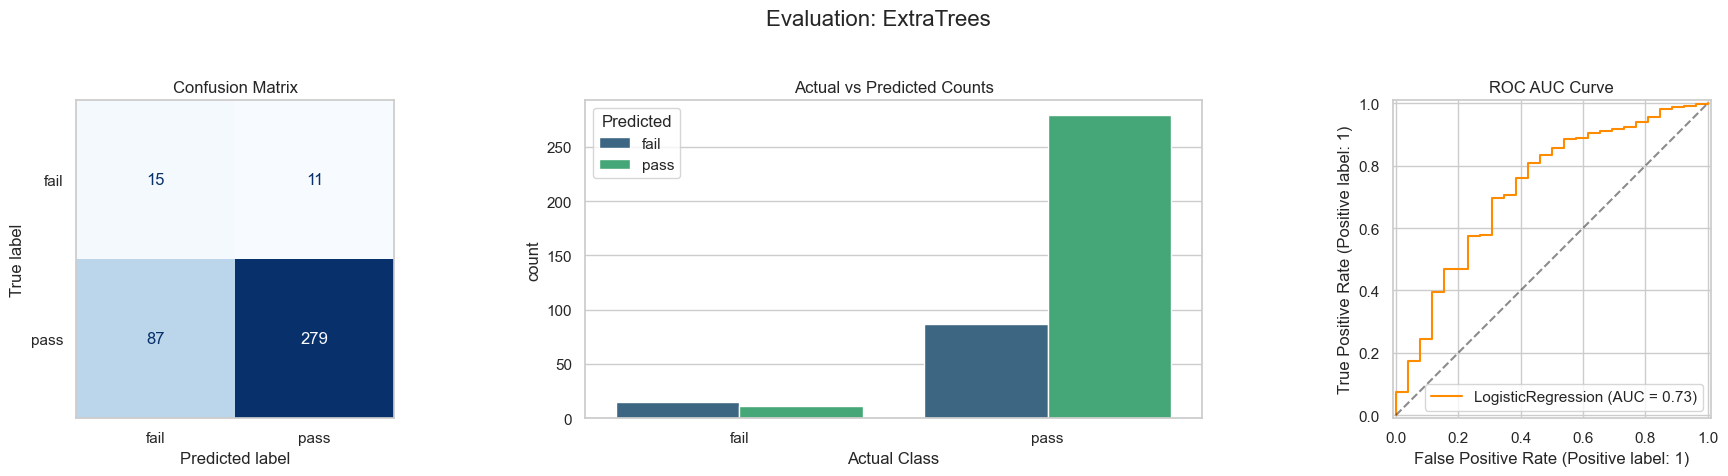

In [46]:
MAX_FEATURES=50

start_sel = time.time()

et_selector = ExtraTreesClassifier(
    n_estimators=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
et_selector.fit(X_train_np, y_train)
raw_non_zero = np.sum(et_selector.feature_importances_ != 0)
print(f"The ExtraTrees model found {raw_non_zero} features with non-zero weights.")

model_selector = SelectFromModel(
    et_selector,
    max_features=MAX_FEATURES,
    threshold=1e-5,
    prefit=True
)
X_train_et = model_selector.fit_transform(X_train_np, y_train)
X_test_et = model_selector.transform(X_test_np)

sel_time = time.time() - start_sel

evaluate_selection_method(
    X_train_sel=X_train_et,
    X_test_sel=X_test_et,
    y_train=y_train,
    y_test=y_test,
    method_name="ExtraTrees",
    selection_time_sec=sel_time,
    category="Embedded",
    original_num_features=baseline_n_features,
)

### Hibridne metode
Hibridni pristupi kombinuju vise strategija (npr. brzo filtriranje radi smanjenja prostora pretrage, a zatim wrapper ili ugradjenu metodu radi dodatnog preciziranja).
Ovo je cesto jedini praktican nacin za primenu racunski zahtevnih metoda na skupovima sa $p \approx 20.000+$ karakteristika.

#### Hybrid 1: Var -> MI pool -> RFE refinement
Jeftino smanjiti broj karakteristika (varijansa + MI), a zatim primeniti wrapper metodu (`RFE`) nad smanjenim skupom.
- Faza formiranja skupa: `SelectKBest(mutual_info_classif)` nad matricom nakon filtriranja po varijansi.
- Faza preciziranja: `RFE(LogisticRegression)` nad dobijenim skupom karakteristika.


Method: Var -> MI(500) -> RFE(50)
Features: 50
Removed features: 516
MCC Score: 0.2239 | F1 (Macro): 0.5766 | Recall (Class 0): 0.5385
Times: Selection 4.27s | Train 0.02s


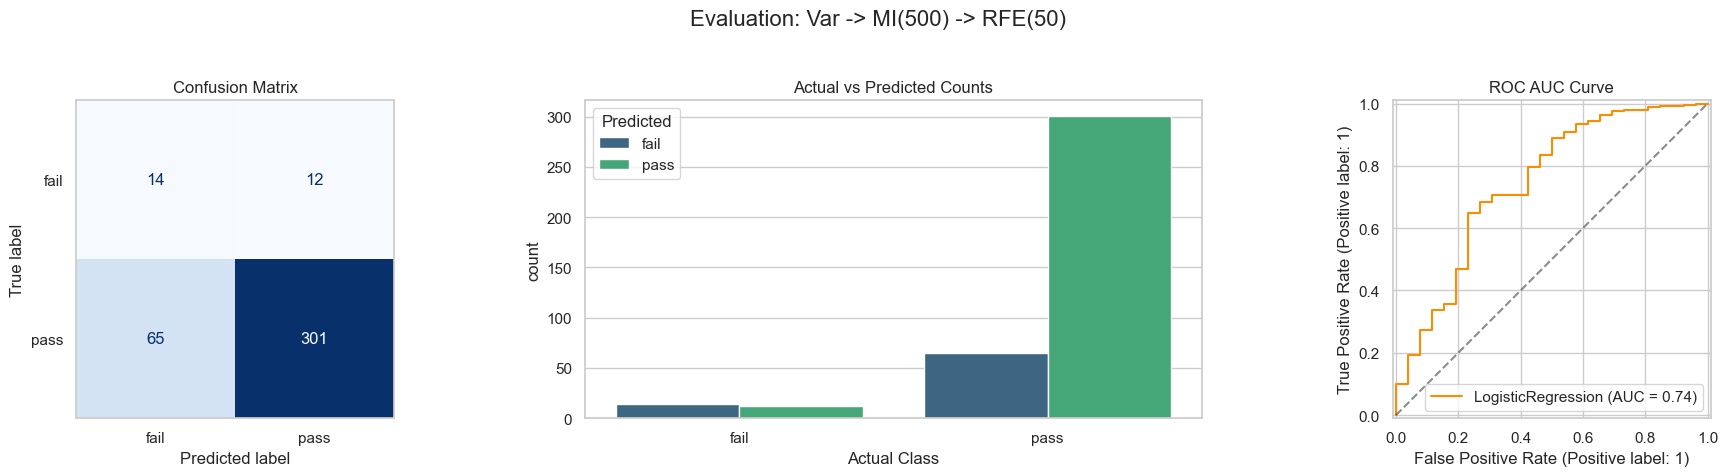

In [ ]:
start_sel = time.time()
HYB_POOL = 500
HYB_SELECT = 50

# MI on variance-filtered matrix
hyb_mi_d = SelectKBest(
    score_func=mutual_info_classif,
    k=min(HYB_POOL, X_train_var.shape[1]),
 )
X_train_hyb_pool_d = hyb_mi_d.fit_transform(X_train_var, y_train)
X_test_hyb_pool_d = hyb_mi_d.transform(X_test_var)

# RFE (Final feature selection)
hyb_est_d = LogisticRegression(
    max_iter=3000,
    solver='lbfgs',
    class_weight='balanced',
 )
hyb_rfe_d = RFE(hyb_est_d, n_features_to_select=min(HYB_SELECT, X_train_hyb_pool_d.shape[1]), step=25)
X_train_hyb_d = hyb_rfe_d.fit_transform(X_train_hyb_pool_d, y_train)
X_test_hyb_d = hyb_rfe_d.transform(X_test_hyb_pool_d)

sel_time = time.time() - start_sel
evaluate_selection_method(
    X_train_sel=X_train_hyb_d,
    X_test_sel=X_test_hyb_d,
    y_train=y_train,
    y_test=y_test,
    method_name=f"Var -> MI({HYB_POOL}) -> RFE({min(HYB_SELECT, X_train_hyb_pool_d.shape[1])})",
    selection_time_sec=sel_time,
    category="Hybrid",
    original_num_features=baseline_n_features,
 )

#### Hybrid 2: Var -> Chi-Square -> RFE refinement


Method: Var -> Chi2 -> RFE
Features: 50
Removed features: 516
MCC Score: 0.1860 | F1 (Macro): 0.4896 | Recall (Class 0): 0.7308
Times: Selection 0.09s | Train 0.01s


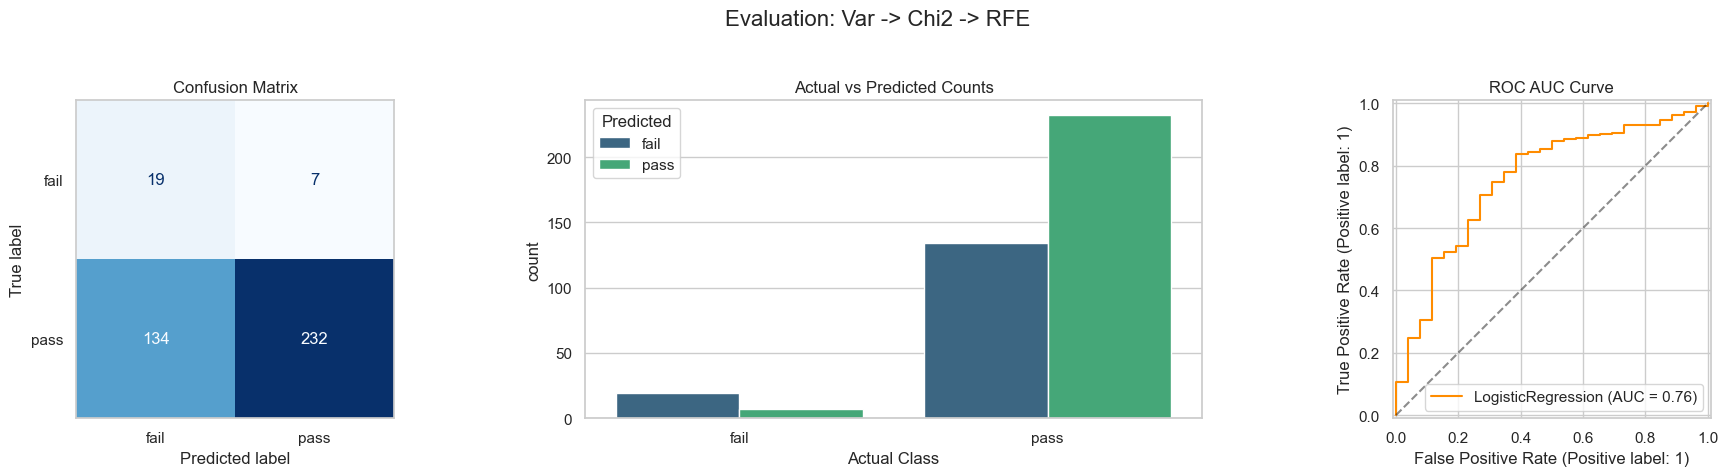

In [ ]:
start_sel = time.time()

# Variance Threshold
var_thresh = VarianceThreshold(threshold=0.1)
X_train_v = var_thresh.fit_transform(X_train_np)

# Chi-Square (Reduces to top 100)
minmax = MinMaxScaler()
X_train_v_nonneg = minmax.fit_transform(X_train_v)

chi_filter = SelectKBest(score_func=chi2, k=100)
X_train_v_chi = chi_filter.fit_transform(X_train_v_nonneg, y_train)

# RFE (Final 50 features)
rfe_estimator = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=50, step=25)

X_train_final = rfe_selector.fit_transform(X_train_v_chi, y_train)
X_test_final = rfe_selector.transform(chi_filter.transform(var_thresh.transform(X_test_np)))

sel_time = time.time() - start_sel
evaluate_selection_method(
    X_train_final, 
    X_test_final, 
    y_train, 
    y_test, 
    "Var -> Chi2 -> RFE", 
    sel_time,
    category="Hybrid",
    original_num_features=baseline_n_features
)

## Globalno poredjenje i vizualizacije metoda
Rezultati sacuvani u recniku bice objedninjeni u jedinstveni DataFrame, na osnovu koga ce biti generisani analiticki grafikoni koji pruzaju pregled najvaznijih nalaza.

### Generator tabele za poredjenje
Ova metoda pretvara registar rezultata u pregledan i sortiran DataFrame i istice najbolje rezultate u svakoj kategoriji (najveci MCC, najmanje vreme izvrsavanja itd.).

In [49]:
def generate_comparison_table(registry):
    df = pd.DataFrame(registry).T
    
    cols_to_fix = ['MCC', 'Recall (Fail)', 'Reduction %', 'Num Features', 'Total Time (s)']
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col])
    
    # Sort by MCC descending
    df = df.sort_values(by='MCC', ascending=False)
    
    return df.round(4)

In [50]:
def plot_time_analysis(registry):
    df = pd.DataFrame(registry).T
    
    # Stacked bar chart for Selection vs Train time
    time_df = df[['Selection Time (s)', 'Train Time (s)']]
    
    ax = time_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4e79a7', '#f28e2b'])
    
    plt.title('Execution Time Breakdown by Method', fontsize=14)
    plt.xlabel('Seconds')
    plt.ylabel('Feature Selection Method')
    plt.legend(title="Process Phase")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Total time labels to the end of bars
    for i, total in enumerate(df['Total Time (s)']):
        ax.text(total, i, f' {total:.2f}s', va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()


def display_all_category_tables(registries):
    master_list = []
    
    for category, registry in registries.items():
        if not registry: continue
        
        print(f"\n### {category} Methods Comparison")
        print("-" * 30)
        
        df = generate_comparison_table(registry)
        display(df)
        
        # Prepare data for the global graphs
        temp_df = df.copy()
        temp_df['Category'] = category
        master_list.append(temp_df)
    
    # Return a combined dataframe for the plotting functions
    df = pd.concat(master_list)
    df = df.sort_values(by='MCC', ascending=False)
    return df

In [51]:
master_df = display_all_category_tables(registries)
print(f"\n### All Methods Comparison")
print("-" * 30)
display(master_df)


### Filter Methods Comparison
------------------------------


,Num Features,Reduction %,MCC,F1 Macro,Accuracy,Recall (Fail),Selection Time (s),Train Time (s),Total Time (s)
Chi-Square,50.0,91.17,0.1965,0.5356,0.7321,0.6154,0.0294,0.0105,0.0399
Pearson Correlation,50.0,91.17,0.1733,0.5366,0.7500,0.5385,1.0238,0.0254,1.0492
Fisher's Score (F-Test),50.0,91.17,0.1733,0.5366,0.7500,0.5385,0.0306,0.0254,0.0560
Baseline (All Features),566.0,0.00,0.1256,0.5506,0.8316,0.3077,0.0000,0.3617,0.3617
Variance Threshold,450.0,20.49,0.1256,0.5506,0.8316,0.3077,0.0287,0.3643,0.3930
Mutual Information,50.0,91.17,0.0970,0.4813,0.6709,0.5000,3.8942,0.0212,3.9153



### Wrapper Methods Comparison
------------------------------


,Num Features,Reduction %,MCC,F1 Macro,Accuracy,Recall (Fail),Selection Time (s),Train Time (s),Total Time (s)
RFE (Full Set -> 20),20.0,96.47,0.2675,0.5421,0.7066,0.8077,2.3952,0.0067,2.4020
RFE (F-test pool 100 → 20),20.0,96.47,0.2193,0.5445,0.7372,0.6538,3.1934,0.0046,3.1980
SFS (Chi2 Pool 100 -> 20),20.0,96.47,0.2006,0.5586,0.7806,0.5385,45.8673,0.0044,45.8717
SBE (Chi2 Pool 100 → 20),20.0,96.47,0.1839,0.5354,0.7398,0.5769,161.9119,0.0049,161.9168
SFS (Full Set -> 20),20.0,96.47,0.1641,0.5184,0.7143,0.5769,303.3643,0.0033,303.3676



### Embedded Methods Comparison
------------------------------


,Num Features,Reduction %,MCC,F1 Macro,Accuracy,Recall (Fail),Selection Time (s),Train Time (s),Total Time (s)
"LASSO (L1), C=0.01",5.0,99.12,0.2707,0.6035,0.8265,0.5769,0.0495,0.0032,0.0527
"Ridge (L2), C=1.0",50.0,91.17,0.2303,0.5729,0.7908,0.5769,0.1212,0.0217,0.1429
ExtraTrees,50.0,91.17,0.1924,0.5425,0.7500,0.5769,2.0064,0.0212,2.0276
"LASSO (L1), C=1.0",50.0,91.17,0.1678,0.5508,0.7883,0.4615,1.7616,0.0194,1.7811
"ElasticNet (L1+L2), C=1.0",50.0,91.17,0.1003,0.5160,0.7577,0.3846,37.4713,0.0199,37.4912
Decision Tree (Gini),55.0,90.28,0.0293,0.4668,0.6837,0.3462,0.5005,0.0180,0.5185



### Hybrid Methods Comparison
------------------------------


,Num Features,Reduction %,MCC,F1 Macro,Accuracy,Recall (Fail),Selection Time (s),Train Time (s),Total Time (s)
Var -> MI(500) -> RFE(50),50.0,91.17,0.2239,0.5766,0.8036,0.5385,4.2686,0.0196,4.2881
Var -> Chi2 -> RFE,50.0,91.17,0.1860,0.4896,0.6403,0.7308,0.0940,0.0115,0.1055



### All Methods Comparison
------------------------------


,Num Features,Reduction %,MCC,F1 Macro,Accuracy,Recall (Fail),Selection Time (s),Train Time (s),Total Time (s),Category
"LASSO (L1), C=0.01",5.0,99.12,0.2707,0.6035,0.8265,0.5769,0.0495,0.0032,0.0527,Embedded
RFE (Full Set -> 20),20.0,96.47,0.2675,0.5421,0.7066,0.8077,2.3952,0.0067,2.4020,Wrapper
"Ridge (L2), C=1.0",50.0,91.17,0.2303,0.5729,0.7908,0.5769,0.1212,0.0217,0.1429,Embedded
Var -> MI(500) -> RFE(50),50.0,91.17,0.2239,0.5766,0.8036,0.5385,4.2686,0.0196,4.2881,Hybrid
RFE (F-test pool 100 → 20),20.0,96.47,0.2193,0.5445,0.7372,0.6538,3.1934,0.0046,3.1980,Wrapper
SFS (Chi2 Pool 100 -> 20),20.0,96.47,0.2006,0.5586,0.7806,0.5385,45.8673,0.0044,45.8717,Wrapper
Chi-Square,50.0,91.17,0.1965,0.5356,0.7321,0.6154,0.0294,0.0105,0.0399,Filter
ExtraTrees,50.0,91.17,0.1924,0.5425,0.7500,0.5769,2.0064,0.0212,2.0276,Embedded
Var -> Chi2 -> RFE,50.0,91.17,0.1860,0.4896,0.6403,0.7308,0.0940,0.0115,0.1055,Hybrid
SBE (Chi2 Pool 100 → 20),20.0,96.47,0.1839,0.5354,0.7398,0.5769,161.9119,0.0049,161.9168,Wrapper


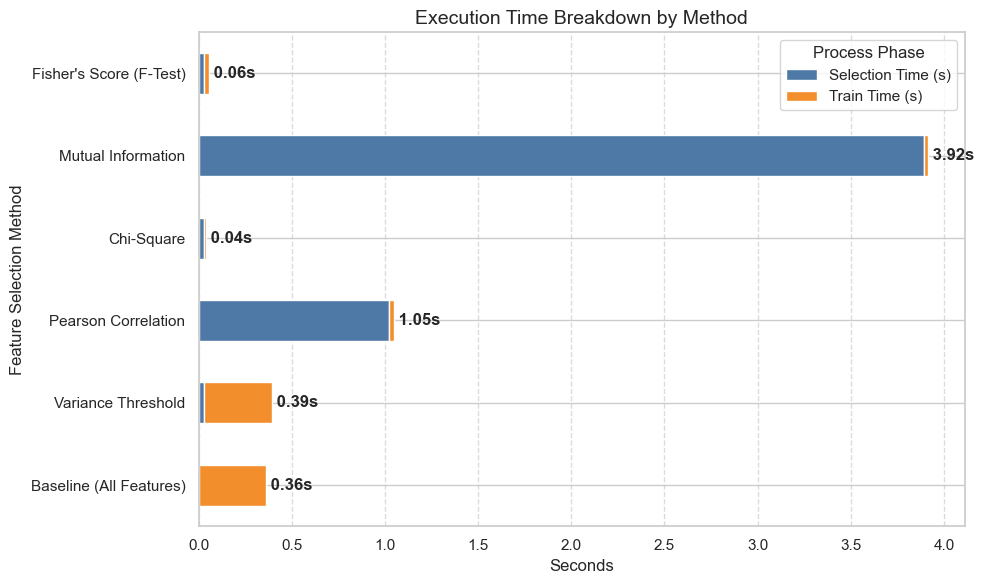

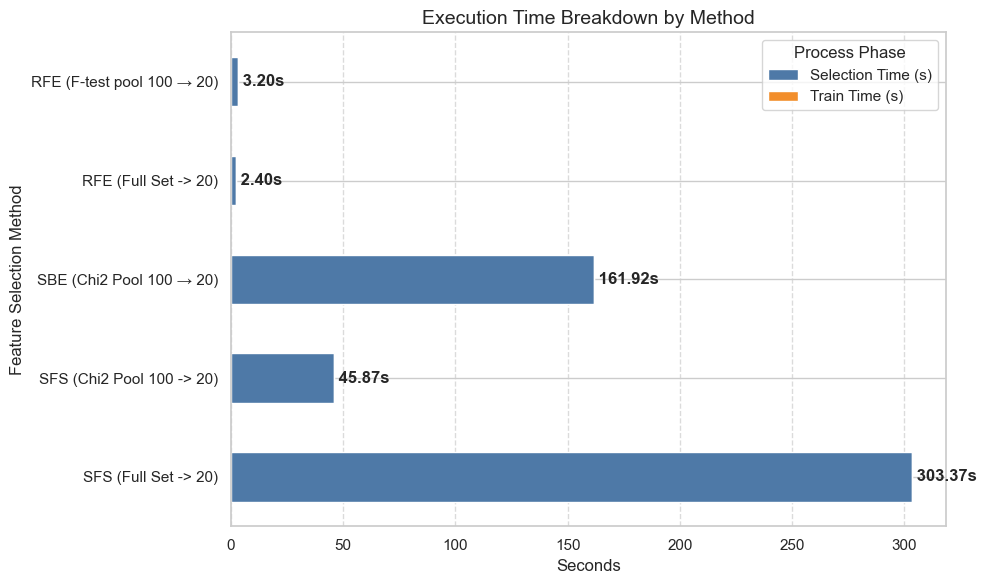

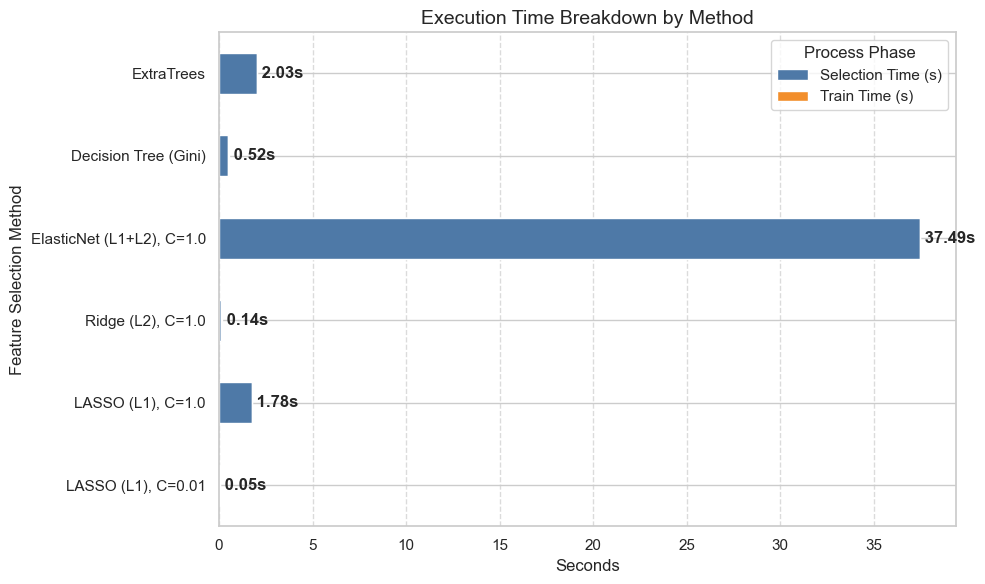

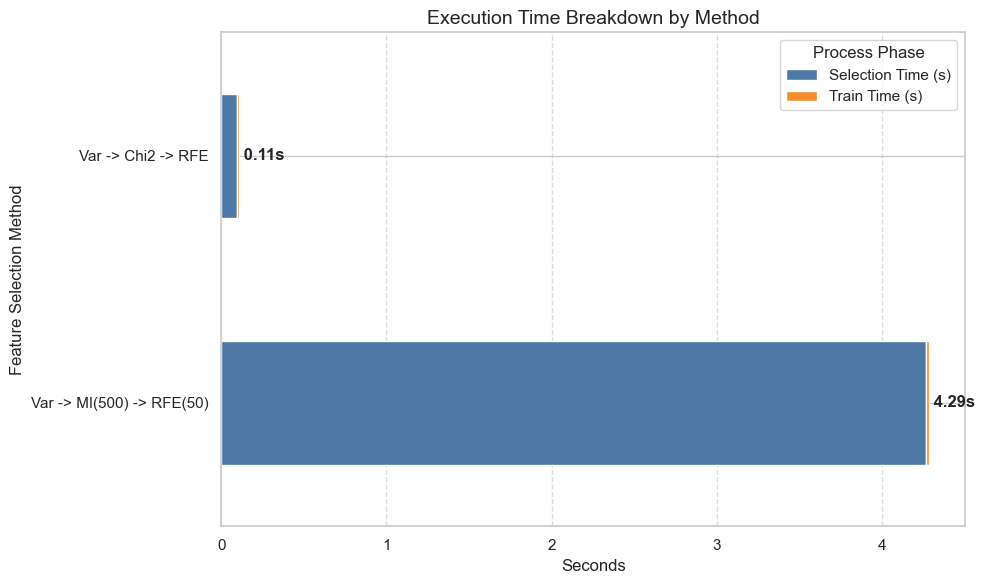

In [52]:
plot_time_analysis(registries['Filter'])
plot_time_analysis(registries['Wrapper'])
plot_time_analysis(registries['Embedded'])
plot_time_analysis(registries['Hybrid'])

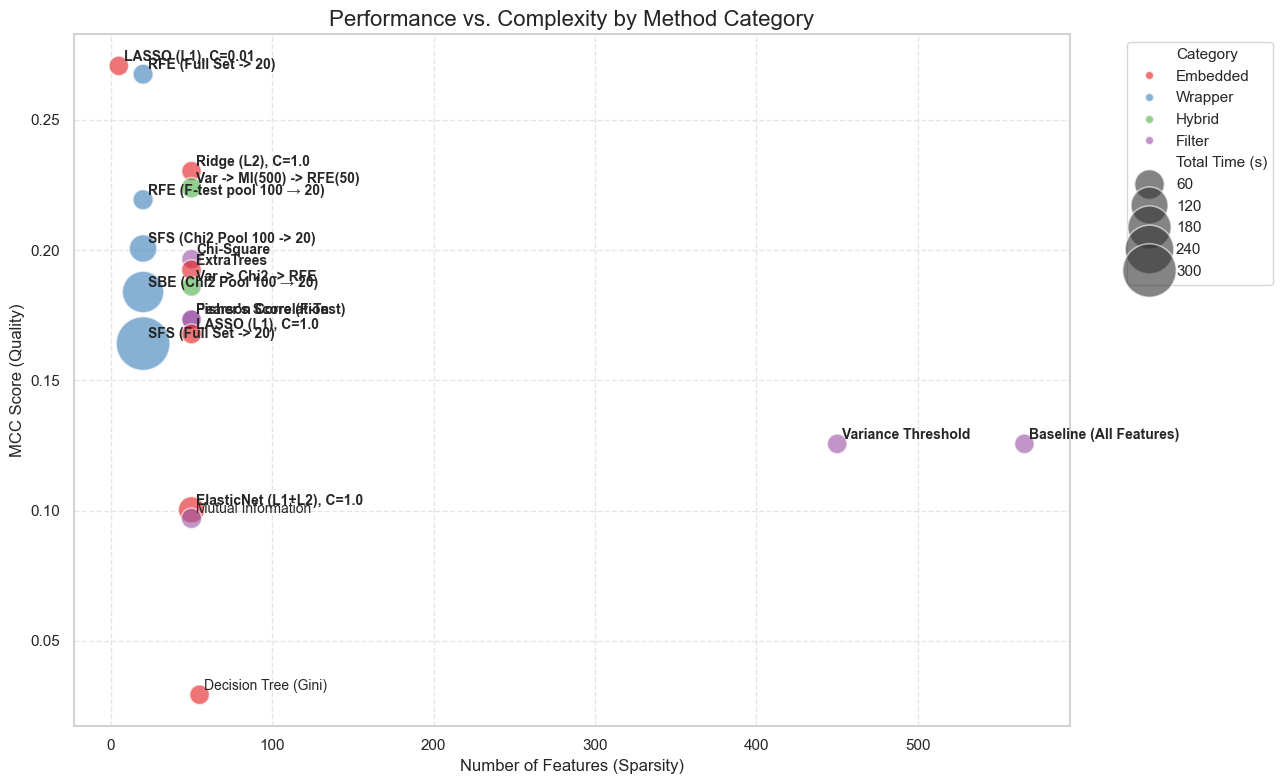

In [53]:
def plot_categorized_performance(master_df):
    plt.figure(figsize=(13, 8))
    sns.set_style("whitegrid")
    
    # x=Features, y=MCC, color=Category, size=Time
    scatter = sns.scatterplot(
        data=master_df.reset_index(),
        x='Num Features',
        y='MCC',
        hue='Category',
        size='Total Time (s)',
        sizes=(200, 1500),
        alpha=0.6,
        palette='Set1'
    )
    
    # Labels
    for i in range(master_df.shape[0]):
        plt.text(
            master_df['Num Features'].iloc[i] + 3, 
            master_df['MCC'].iloc[i] + 0.002, 
            master_df.index[i], 
            fontsize=10, fontweight='bold' if master_df['MCC'].iloc[i] > 0.1 else 'normal'
        )
        
    plt.title('Performance vs. Complexity by Method Category', fontsize=16)
    plt.xlabel('Number of Features (Sparsity)', fontsize=12)
    plt.ylabel('MCC Score (Quality)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_categorized_performance(master_df)

In [ ]:
def plot_method_trends(data):   
    # If input is a registry dict -> convert to dataframe
    if isinstance(data, dict):
        category = None

        if 'registries' in globals():
            for cat_name, registry_obj in registries.items():
                if registry_obj is data:
                    category = cat_name
                    break

        df = generate_comparison_table(data)

        if category:
            title = f'{category} Methods: Computational Cost vs. Prediction Quality'
        else:
            title = 'Feature Selection Methods: Computational Cost vs. Prediction Quality'
    else:
        df = data.copy()

        if 'Category' in df.columns:
            unique_categories = df['Category'].dropna().unique()

            if len(unique_categories) == 1:
                title = (
                    f'{unique_categories[0]} Methods: '
                    'Computational Cost vs. Prediction Quality'
                )
            else:
                title = (
                    'All Feature Selection Categories: '
                    'Computational Cost vs. Prediction Quality'
                )
        else:
            title = 'Computational Cost vs. Prediction Quality by Method'


    # Sort by MCC to show methods from worst to best
    df_sorted = (
        df.sort_values(by='MCC')
          .reset_index()
          .rename(columns={'index': 'Method'})
    )

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # 1. Top Plot: Time Analysis
    ax0.plot(
        df_sorted['Method'],
        df_sorted['Total Time (s)'],
        marker='o',
        linestyle='-',
        label='Total Execution Time (s)',
        color='#4e79a7'
    )

    ax0.set_ylabel('Total Time (Seconds)', fontsize=11, fontweight='bold')
    ax0.set_title(
        title,
        fontsize=14,
        pad=15
    )

    ax0.grid(True, linestyle='--', alpha=0.6)
    ax0.legend(loc='upper left')

    # 2. Bottom Plot: Accuracy Metrics
    ax1.plot(
        df_sorted['Method'],
        df_sorted['F1 Macro'],
        marker='s',
        label='F1 Score (Macro)',
        c='r',
        alpha=0.8
    )

    ax1.plot(
        df_sorted['Method'],
        df_sorted['Accuracy'],
        marker='s',
        label='Accuracy',
        c='b',
        alpha=0.8
    )

    ax1.plot(
        df_sorted['Method'],
        df_sorted['MCC'],
        marker='D',
        label='MCC Score',
        c='darkgreen',
        linewidth=2
    )

    ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax1.set_xlabel(
        'Feature Selection Method (Sorted by Performance)',
        fontsize=12
    )

    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Rotate labels
    plt.xticks(rotation=45, ha='right')

    # Highlight best method
    ax1.axvline(
        x=len(df_sorted) - 1,
        color='purple',
        linestyle=':',
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

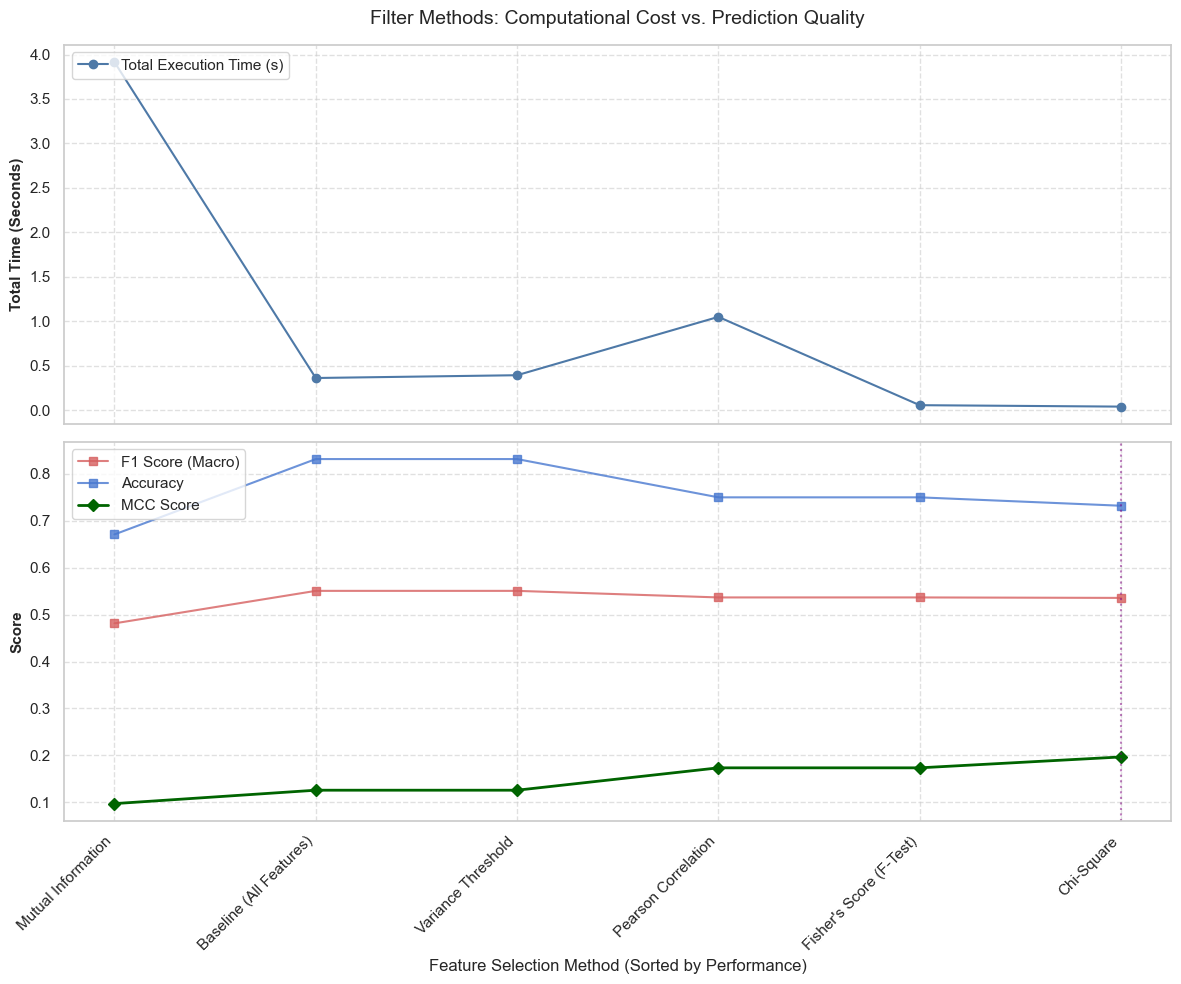

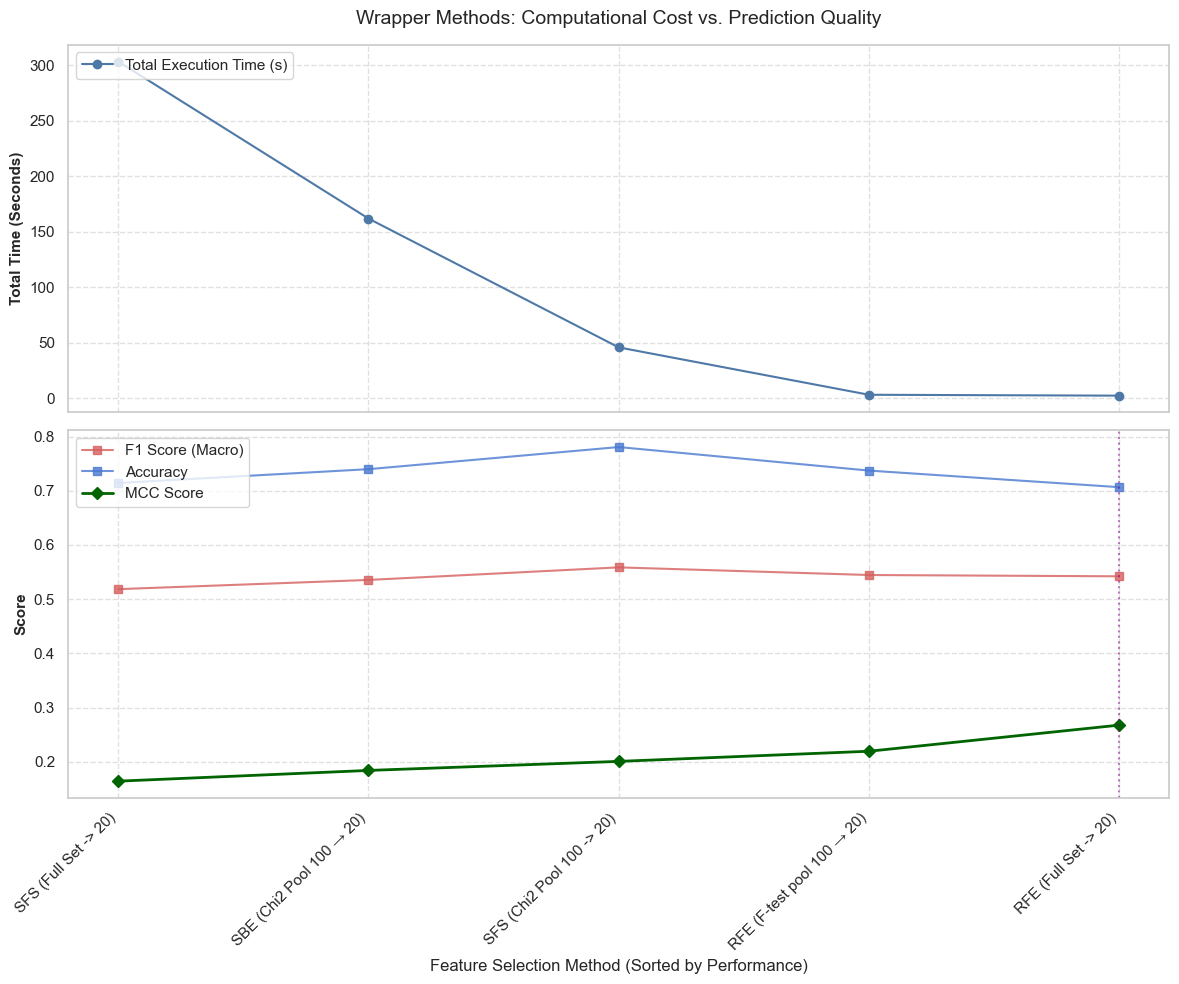

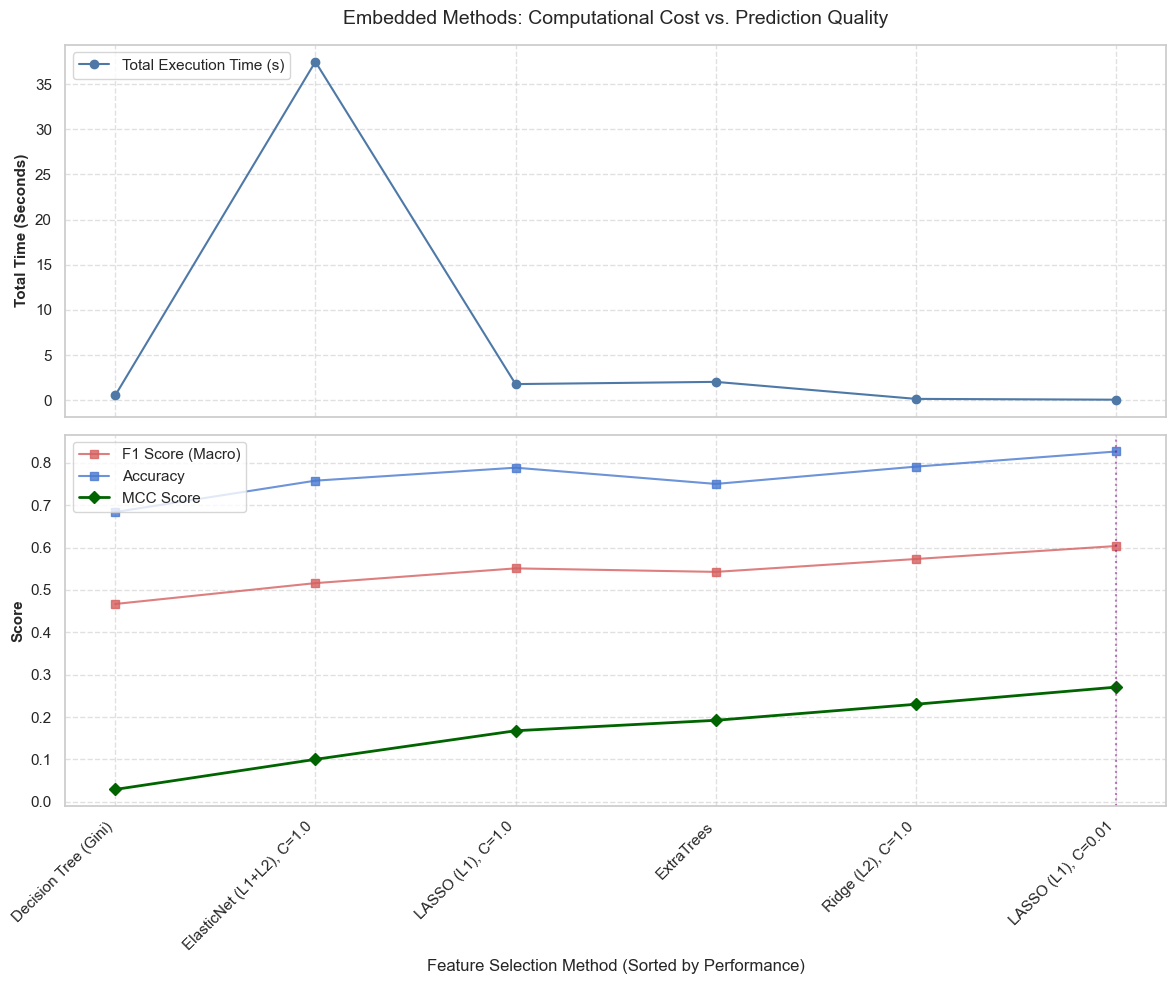

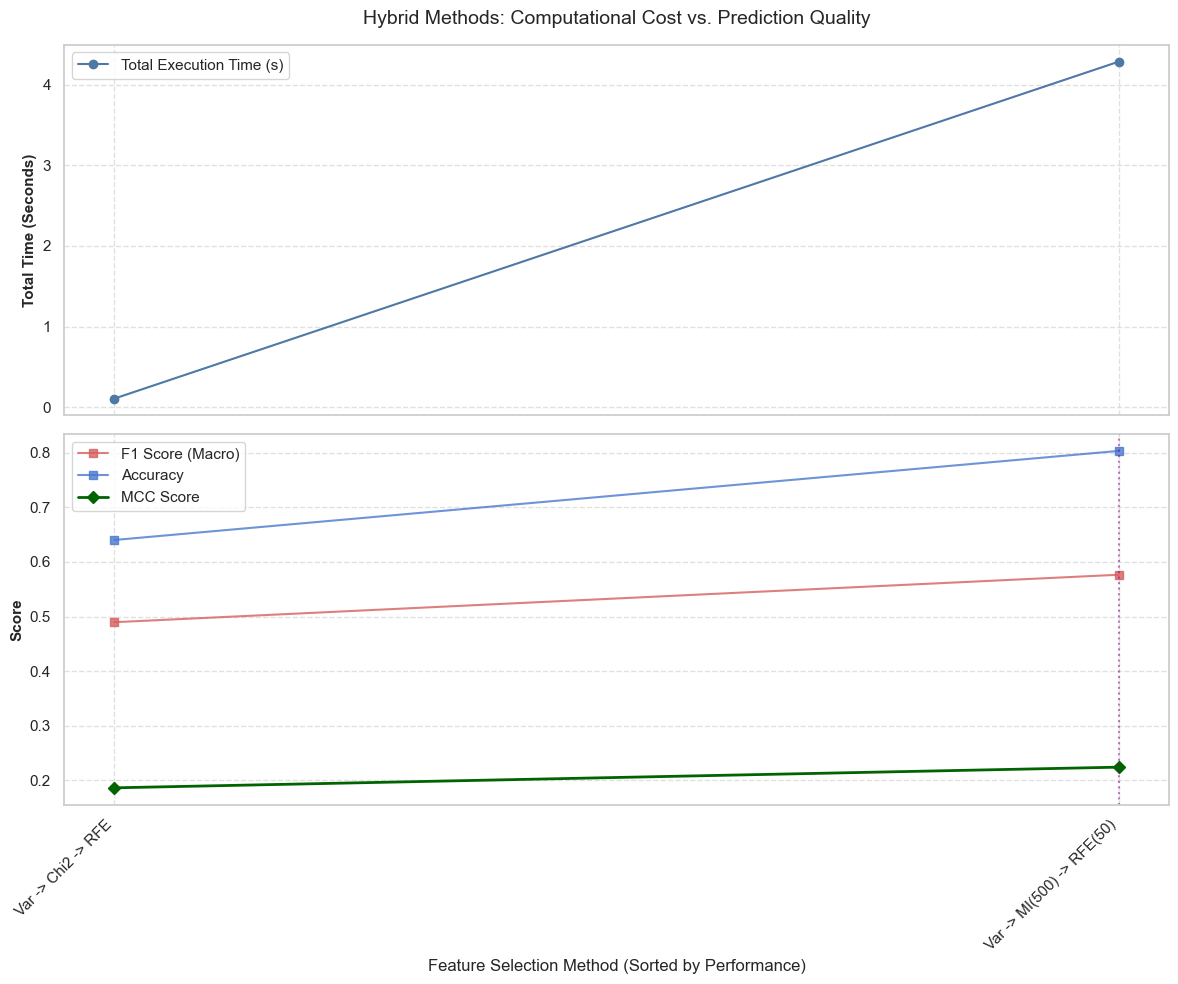

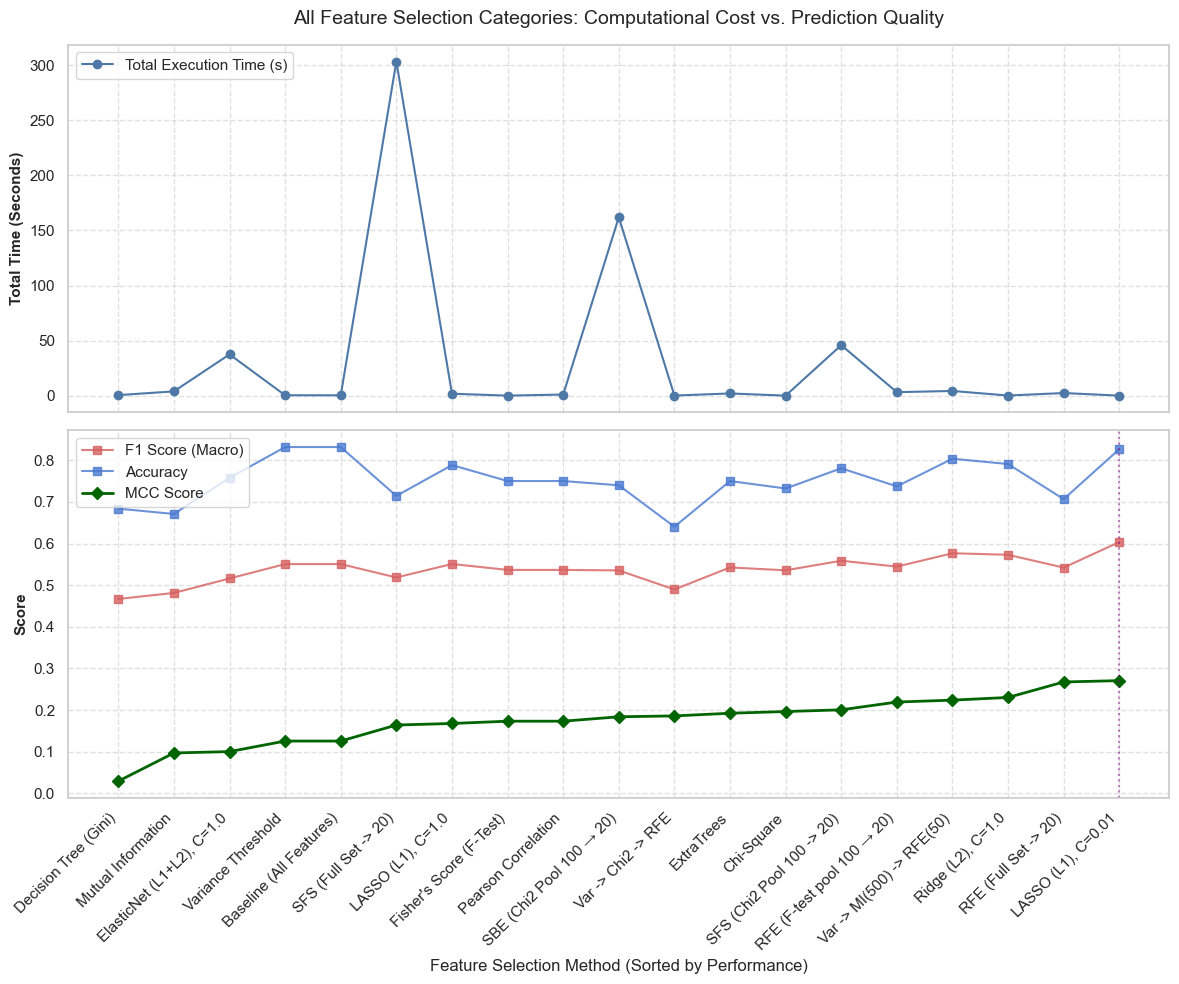

In [59]:
plot_method_trends(registries['Filter'])
plot_method_trends(registries['Wrapper'])
plot_method_trends(registries['Embedded'])
plot_method_trends(registries['Hybrid'])
plot_method_trends(master_df)

In [ ]:
def print_executive_summary(master_df):
    summary = master_df.copy()
    # Calculate a "Utility Score" (Arbitrary but useful: MCC / Time)
    summary['Utility'] = summary['MCC'] / (np.log1p(summary['Total Time (s)']) + 1)
    
    print("FINAL RESEARCH RANKINGS")
    print("="*40)
    print(summary[['MCC', 'Num Features', 'Total Time (s)']].sort_values(by='MCC', ascending=False).head(5))

print_executive_summary(master_df)

FINAL RESEARCH RANKINGS
                               MCC  Num Features  Total Time (s)
LASSO (L1), C=0.01          0.2707           5.0          0.0412
RFE (Full Set -> 20)        0.2675          20.0          2.0556
Ridge (L2), C=1.0           0.2303          50.0          0.1161
Var -> MI(500) -> RFE(50)   0.2239          50.0          3.6202
RFE (F-test pool 100 → 20)  0.2193          20.0          2.7282


Na osnovu sprovedenih eksperimenata moze se zakljuciti da je redukcija broja karakteristika omogucila znacajno pojednostavljenje modela uz zadrzavanje dobrih klasifikacionih performansi. Razlicite metode pokazale su razlicite kompromise izmedju tacnosti, broja izabranih karakteristika i vremena izvrsavanja.

Najbolje rezultate ostvarila je **LASSO (L1 logisticka regresija)**, koja je postigla najveci MCC (0.2707), pri cemu je zadrzala samo **5 karakteristika** i imala ubedljivo najmanje vreme izvrsavanja (0.041 s). Ovakav rezultat pokazuje da mali broj pazljivo odabranih karakteristika moze biti dovoljan za uspesnu klasifikaciju, sto doprinosi jednostavnijem i lakse interpretabilnom modelu.

**RFE primenjen na kompletnom skupu podataka** ostvario je veoma slican MCC (0.2675), ali uz izbor 20 karakteristika i gotovo 50 puta duze vreme izvrsavanja. Ovo ukazuje da wrapper metode mogu dati konkurentne rezultate, ali po cenu znatno vece racunske slozenosti.

**Ridge (L2)** i **hibridni pristup Var -> MI -> RFE** ostvarili su nesto slabije performanse, ali predstavljaju razuman kompromis kada je potrebna veca stabilnost modela ili kada se zeli kombinovati vise strategija selekcije karakteristika. Hibridni pristup posebno pokazuje da prethodno filtriranje moze znacajno smanjiti prostor pretrage pre primene zahtevnijih wrapper metoda.